This notebook is an appendix to the article "Architectural Transparency, Energy Efficiency and the Environment: Insulating Glass Units and their Material, Energy and Carbon Footprints in the European Union, France and Belgium from 1945 to 2022" by Souvion and Stefan. It outlines the data processing and figure generation process that accompanied the writing of this article.

The raw data are extracted from an Excel files untitled "S1_IGU_RawData_VPython.xlsx".

# Set Up

In [1]:
import os
import re
import sys

import pathlib
from pathlib import Path

import sqlite3

import pandas as pd
import numpy as np

from scipy import stats

import math

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns

from IPython.display import display

from copy import deepcopy
import logging as log

import pickle
import pylab

In [2]:
# Helper (support)
from support import input_helper

In [3]:
# Directory with IGU datasets:
ROOT_DIR = "RawData"

# Define path to save figures:
path_img = os.path.abspath(os.path.join('outputs', 'IMG'))
if not os.path.exists(path_img):
    os.makedirs(path_img)
print(f'Images will be saved in {path_img}')

Images will be saved in C:\Users\souvi\Documents\Recherche\Papers\2025_MEFA of IGU\Python_MFA_IGU\outputs\IMG


In [4]:
# Define size of figure:
mpl.rcParams['figure.figsize'] = (16, 10)

In [5]:
# Define seaborn main parameters:
sns.set_style("ticks")
sns.color_palette("colorblind")
sns.set_context("paper", font_scale=1.5,
                rc={"axes.titlesize": 12, "lines.linewidth": 1.2,
                    "legend.fontsize": 9, "legend.title_fontsize": 9})

In [6]:
pd.set_option('precision', 2)

In [7]:
# A custom formatter function which divide by 1000 an axis:
import matplotlib.ticker as tkr


def yfmt1000(x, pos):
    s = f'{x/1000:,.0f}'
    return s

# W/ classes for tick-locating and -formatting:


# A formatter function:
y_1000 = tkr.FuncFormatter(yfmt1000)

# To divide the y-axis by 1000 when needed:
# ax.yaxis.set_major_formatter(y_1000)

In [8]:
# A function used to define the thickness of x and y axis:
def style_ax(ax):
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(0.5)
        ax.tick_params(width=0.5)
        ax.set_xlabel(None)
    return ax

In [9]:
# A keyword to export figures, or not:
export = True

# Upload Datasets

In [10]:
# Dataset:
raw_data = input_helper.get_data(
    'S1_IGU_RawData_VPython.xlsx', directory=ROOT_DIR)

In [11]:
print("raw_data, sheet names = \n {}\n".format(raw_data.sheet_names))

raw_data, sheet names = 
 ['CoverSheet', 'References', 'Stock_EU', 'Prod_EU', 'Import_EU', 'Export_EU', 'Thickness_EU', 'CO2Emissions_EU', 'Energy_Intensity_EU', 'Consumption_FR', 'Prod_FR', 'Import_FR', 'Export_FR', 'Population_FR', 'Thickness_FR', 'RawMat_Intensity_FR', 'Energy_Intensity_FR', 'CO2Emissions_FR', 'Consumption_BE', 'Prod_BE', 'Import_BE', 'Export_BE', 'Thickness_BE', 'Energy_Intensity_BE', 'Population_BE']



# Material, Energy and Carbon Intensity in the Flat Glass Industry

See: Souviron J and A Z Khan. (2021). "The Materiality of Transparency: An Environmental Analysis of the Architectural Flat Glass Industry since 1945 in Europe, France and Belgium". _Resources, Conservation and Recycling_. DOI: 10.1016/j.resconrec.2021.105779.

## Material Intensity since 1945, France

In [12]:
# Creating a DataFrame for material intensity:
df_rawmat = raw_data.parse('RawMat_Intensity_FR').set_index('year')

df_rawmat['cullet, kg/kg'] = (df_rawmat['internal cullet, kg/kg']
                              + df_rawmat['external cullet, kg/kg'])

In [13]:
# Estimating total material intensity (sum of the intensities per material):
materials = ['sand', 'cullet', 'sodium carbonate',
             'limestone', 'dolomite', 'feldspar']
print(materials)

df_rawmat['Total raw materials, kg/kg'] = 0
for mat in materials:
    df_rawmat['Total raw materials, kg/kg'] = (
        df_rawmat[f"{mat}, kg/kg"]
        + df_rawmat['Total raw materials, kg/kg']
    )

['sand', 'cullet', 'sodium carbonate', 'limestone', 'dolomite', 'feldspar']


In [14]:
# Estimate the material intensity without cullet:
materials.remove('cullet')
df_rawmat['Total raw mat w/o cullet, kg/kg'] = 0
for mat in materials:
    df_rawmat['Total raw mat w/o cullet, kg/kg'] = (
        df_rawmat[f"{mat}, kg/kg"]
        + df_rawmat['Total raw mat w/o cullet, kg/kg']
    )

materials = ['sand', 'cullet', 'sodium carbonate',
             'limestone', 'dolomite', 'feldspar']

## Energy Intensity since 1945, France and Belgium

In [15]:
# Create a DataFrame for the energy intensity in France:
df_fr_energy = raw_data.parse('Energy_Intensity_FR').set_index('year')
df_be_energy = raw_data.parse('Energy_Intensity_BE').set_index('year')

# Create a unique DataFrame for FR and BE flat glass flows:
df_be_fr_energy = pd.concat(
    [df_fr_energy['fuel oil, GJ/t'],
     df_be_energy['fuel oil, GJ/t'],
     df_fr_energy['natural gas, GJ/t'],
     df_be_energy['natural gas, GJ/t'],
     df_fr_energy['electricity, GJ/t'],
     df_be_energy['electricity, GJ/t']],
    axis=1, keys=[('fuel oil, GJ/t', 'France'),
                  ('fuel oil, GJ/t', 'Belgium'),
                  ('natural gas, GJ/t', 'France'),
                  ('natural gas, GJ/t', 'Belgium'),
                  ('electricity, GJ/t', 'France'),
                  ('electricity, GJ/t', 'Belgium')],
    names=['Info', 'Country']
).stack(dropna=False)

df_be_fr_energy = df_be_fr_energy.unstack()

In [16]:
energies = ['fuel oil', 'natural gas', 'electricity']
fossilfuels = ['fuel oil', 'natural gas']
countries = ['France', 'Belgium']

In [17]:
# Estimate the total energy intensity
# (sum of the intensities per type of energy):
for country in countries:
    df_be_fr_energy[('Total energy, GJ/t', country)] = 0
    for energy in energies:
        df_be_fr_energy[('Total energy, GJ/t', country)] = (
            df_be_fr_energy[('Total energy, GJ/t', country)]
            + df_be_fr_energy[(f"{energy}, GJ/t", country)]
        )

In [18]:
# Estimate the total energy intensity
# (without electricity)
for country in countries:
    df_be_fr_energy[('Total energy w/o elec., GJ/t', country)] = 0
    for energy in fossilfuels:
        df_be_fr_energy[('Total energy w/o elec., GJ/t', country)] = (
            df_be_fr_energy[(
                'Total energy w/o elec., GJ/t', country)]
            + df_be_fr_energy[(f"{energy}, GJ/t", country)]
        )

## Energy Intensity in the EU since 1970

In [19]:
# Create a DataFrame for the energy intensity in the EU:
df_eu_energy = raw_data.parse('Energy_Intensity_EU').set_index('year')

In [20]:
# Estimate the total energy intensity
# (sum of the intensities per type of energy)
# In Europe:
df_eu_energy['Total energy, GJ/t'] = 0

for energy in energies:
    df_eu_energy['Total energy, GJ/t'] = (
        df_eu_energy['Total energy, GJ/t']
        + df_eu_energy[f"{energy}, GJ/t"]
    )

In [21]:
# Estimate the total energy intensity
# (without electricity)
df_eu_energy['Total energy w/o elec., GJ/t'] = 0

for energy in fossilfuels:
    df_eu_energy['Total energy w/o elec., GJ/t'] = (
        df_eu_energy['Total energy w/o elec., GJ/t']
        + df_eu_energy[f"{energy}, GJ/t"]
    )

## Carbon Intensity of the Flat Glass Manufacturing Process in France

In [22]:
# Create a DataFrame only with the CO2 emission data:
fr_emissions = raw_data.parse('CO2Emissions_FR').set_index('year')

fr_co2_intensity = fr_emissions[['CO2 glass ind, kg/t']].copy()
fr_co2_intensity.rename(columns={'CO2 glass ind, kg/t': 'CO2 [kg/t]'},
                        inplace=True)

In [23]:
# Interpolate CO2 intensity accoring to a pchip method:
fr_co2_intensity['CO2 interpolated [kg/t]'] = (
    fr_co2_intensity['CO2 [kg/t]'].interpolate('pchip')
)

## Carbon Intensity of the Flat Glass Manufacturing Process in the EU

In [24]:
# Create a DataFrame only with the CO2 emission data:
df_eu_emissions = raw_data.parse('CO2Emissions_EU').set_index('year')

df_eu_co2 = df_eu_emissions[['CO2 glass ind, kg/t']].copy()
df_eu_co2.rename(columns={'CO2 glass ind, kg/t': 'CO2 [kg/t]'},
                 inplace=True)

In [25]:
# Interpolate CO2 intensity accoring to a pchip method:
df_eu_co2['CO2 interpolated [kg/t]'] = (
    df_eu_co2['CO2 [kg/t]'].interpolate('pchip')
)

## Summary

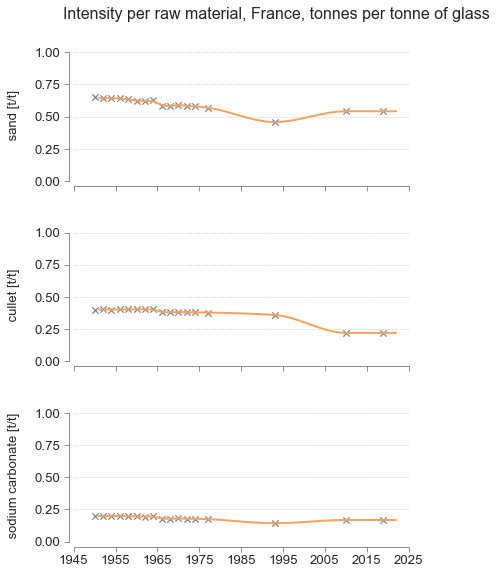

In [26]:
# Plot the material instensity per raw material:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    (df_rawmat[f"{mat}, kg/kg"]
     .interpolate(method='pchip', limit_direction='forward')
     .rolling(3, center=True).mean()
     .plot(ax=ax, c='sandybrown', linewidth=2))

    ax.scatter(x=df_rawmat.index, y=df_rawmat[f"{mat}, kg/kg"],
               s=40, marker='x', c='grey')
    plt.xticks(np.arange(1950, 2021, 10), rotation=45)

    ax.set_ylabel(f" {mat} [t/t]", loc='center', labelpad=15, fontsize=13)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1950, 2025)
ax.set_ylim(0, 1)

ax.minorticks_off()
plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle(
    "Intensity per raw material, France, tonnes per tonne of glass",
    x=0.1, y=0.95, ha='left', fontsize=16)

fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)

plt.show()

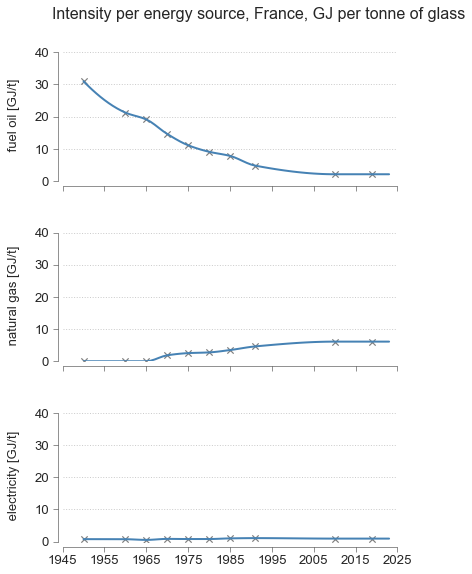

In [27]:
# Plot the energy intensity per source of energy, France:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9)
                         )

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    (df_be_fr_energy[(f"{energy}, GJ/t", "France")]
     .interpolate(method='pchip', limit_direction='forward')
     .plot(ax=ax, color='steelblue', linewidth=2))

    ax.scatter(x=df_be_fr_energy.index,
               y=df_be_fr_energy[(f"{energy}, GJ/t", "France")],
               s=40, marker='x', c='grey')

    ax.set_ylabel(f" {energy} [GJ/t]", loc='center', labelpad=15, fontsize=13)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1950, 2025)
ax.set_ylim(0, 40)

fig.suptitle("Intensity per energy source, France, GJ per tonne of glass",
             x=0.1, y=0.95, ha='left', fontsize=16)
fig.subplots_adjust(hspace=0.4)

ax.minorticks_off()
plt.xticks(np.arange(1945, 2026, 10))

sns.despine(offset=5)

plt.show()

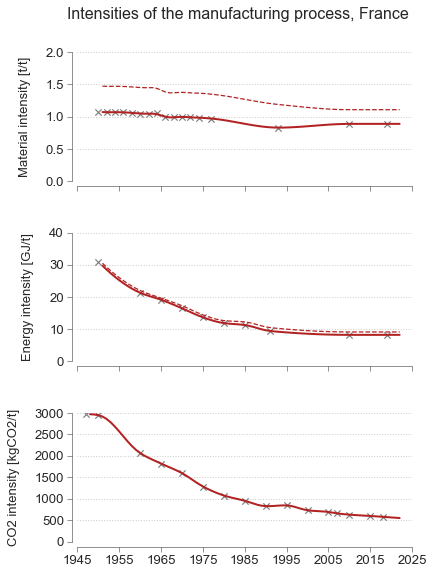

In [28]:
# Plot the intensity for energy, material and CO2 emissions:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

# Material intensity
ax = axes[0]
(df_rawmat['Total raw materials, kg/kg']
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linestyle='--', linewidth=1.25)
 )

(df_rawmat['Total raw mat w/o cullet, kg/kg']
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linestyle='-', linewidth=2)
 )

ax.scatter(x=df_rawmat.index,
           y=df_rawmat['Total raw mat w/o cullet, kg/kg'],
           s=40, marker='x', c='grey')

ax.set_ylabel("Material intensity [t/t]", loc='center',
              labelpad=15, fontsize=13)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 2)
ax.set_xlim(1950, 2025)

# Energy intensity
ax = axes[1]
(df_be_fr_energy[('Total energy, GJ/t', 'France')]
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linestyle='--', linewidth=1.25))

(df_be_fr_energy[('Total energy w/o elec., GJ/t', 'France')]
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linewidth=2))

ax.scatter(x=df_be_fr_energy.index,
           y=df_be_fr_energy[(
               'Total energy w/o elec., GJ/t', 'France')],
           s=40, marker='x', c='grey')

ax.set_ylabel("Energy intensity [GJ/t]", loc='center',
              labelpad=15, fontsize=13)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 40)

# Carbon dioxide intensity
ax = axes[2]
(fr_co2_intensity['CO2 interpolated [kg/t]'].rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linewidth=2))

ax.scatter(x=fr_co2_intensity.index, y=fr_co2_intensity['CO2 [kg/t]'],
           s=40, marker='x', c='grey')

ax.set_ylabel("CO2 intensity [kgCO2/t]", loc='center',
              labelpad=15, fontsize=13)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 3000)

ax.minorticks_off()
plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 3001, 500))

fig.suptitle("Intensities of the manufacturing process, France",
             x=0.1, y=0.95, ha='left', fontsize=16)
fig.subplots_adjust(hspace=0.40)

sns.despine(offset=5)

plt.show()

In [29]:
df_rawmat['Total raw materials, kg/kg'].interpolate(
    method='pchip', limit_direction='forward').to_csv(
    'df_rawmat.csv')

df_be_fr_energy[("Total energy, GJ/t", "Belgium")].interpolate(
    method='pchip', limit_direction='forward').to_csv(
    'df_enerj_be.csv')

df_be_fr_energy[("Total energy, GJ/t", "France")].interpolate(
    method='pchip', limit_direction='forward').to_csv(
    'df_enerj_fr.csv')

fr_co2_intensity['CO2 interpolated [kg/t]'].interpolate(
    method='pchip', limit_direction='forward').to_csv(
    'df_co2_fr.csv')

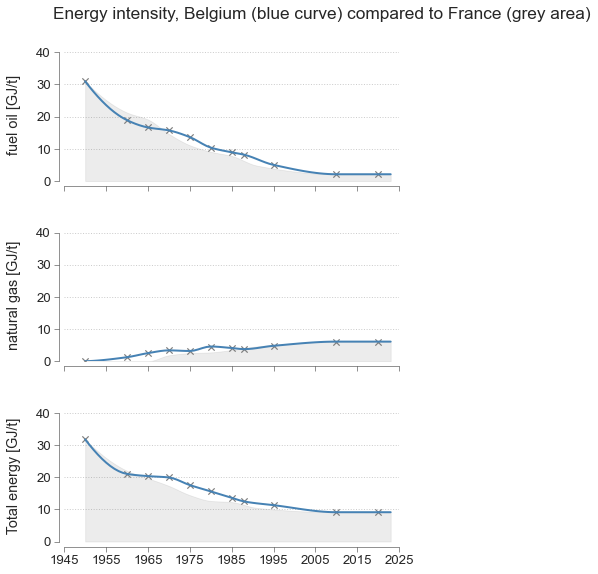

In [30]:
toplot = ['fuel oil', 'natural gas', 'Total energy']

# Plot the energy intensity for Belgium:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9)
                         )

for i, (ax, plot) in enumerate(zip(axes.flatten(), toplot)):
    (df_be_fr_energy[(f"{plot}, GJ/t", "Belgium")]
     .interpolate(method='pchip', limit_direction='forward')
     .plot(ax=ax, color='steelblue', linewidth=2))

    ax.scatter(x=df_be_fr_energy.index,
               y=df_be_fr_energy[(f"{plot}, GJ/t", "Belgium")],
               s=40, marker='x', c='grey')

    x = (df_be_fr_energy.reset_index()['year'])
    y = (df_be_fr_energy[(f"{plot}, GJ/t", "France")]
         .interpolate(method='pchip', limit_direction='forward'))
    ax.fill_between(x, y, color="grey", alpha=0.15)

    ax.set_ylabel(f" {plot} [GJ/t]", loc='center', labelpad=15)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1950, 2020)
ax.set_ylim(0, 40)

fig.suptitle(
    "Energy intensity, Belgium (blue curve) compared to France (grey area)",
    x=0.1, y=0.95, ha='left'
)
fig.subplots_adjust(hspace=0.4)

ax.minorticks_off()
plt.xticks(np.arange(1945, 2026, 10))

sns.despine(offset=5)

plt.show()

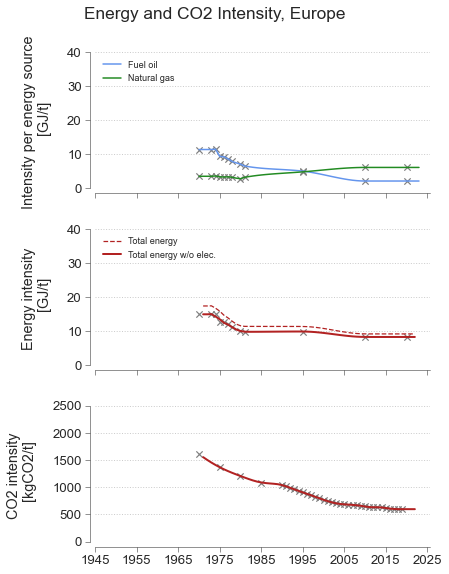

In [31]:
# Plot the intensity for energy, material and CO2 emissions:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

# Intensity, per energy source
ax = axes[0]
(df_eu_energy["fuel oil, GJ/t"]
 .interpolate(method='pchip', limit_direction='forward')
 .plot(ax=ax, color='cornflowerblue', linestyle='-', linewidth=1.5))

ax.scatter(x=df_eu_energy.index,
           y=df_eu_energy["fuel oil, GJ/t"],
           s=40, marker='x', c='grey')

(df_eu_energy["natural gas, GJ/t"]
 .interpolate(method='pchip', limit_direction='forward')
 .plot(ax=ax, color='forestgreen', linewidth=1.5, linestyle='-'))

ax.scatter(x=df_eu_energy.index,
           y=df_eu_energy["natural gas, GJ/t"],
           s=40, marker='x', c='grey')

ax.legend(labels=["Fuel oil", "Natural gas"], loc='upper left', frameon=False)

ax.set_ylabel("Intensity per energy source \n [GJ/t]",
              loc='center', labelpad=15)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 40)


# Energy intensity, total
ax = axes[1]
(df_eu_energy['Total energy, GJ/t']
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linestyle='--', linewidth=1.25))

(df_eu_energy['Total energy w/o elec., GJ/t']
 .interpolate(method='pchip', limit_direction='forward')
 .rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linewidth=2))

ax.scatter(x=df_eu_energy.index,
           y=df_eu_energy['Total energy w/o elec., GJ/t'],
           s=40, marker='x', c='grey')

ax.legend(labels=["Total energy", "Total energy w/o elec."],
          loc='upper left', frameon=False)

ax.set_ylabel("Energy intensity \n [GJ/t]", loc='center', labelpad=15)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 40)

# Carbon dioxide intensity
ax = axes[2]
(df_eu_co2['CO2 interpolated [kg/t]'].rolling(3, center=True).mean()
 .plot(ax=ax, c='firebrick', linewidth=2))

ax.scatter(x=df_eu_co2.index, y=df_eu_co2['CO2 [kg/t]'],
           s=40, marker='x', c='grey')

ax.set_ylabel("CO2 intensity \n [kgCO2/t]", loc='center', labelpad=15)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)
ax.set_ylim(0, 2500)

ax.minorticks_off()

fig.suptitle("Energy and CO2 Intensity, Europe", x=0.1, y=0.95, ha='left')
fig.subplots_adjust(hspace=0.3)

sns.despine(offset=5)

plt.xticks(np.arange(1945, 2026, 10))
plt.show()

# Flows of IGU in Europe

## Creating a Dataframe for the Flows of IGU

In [32]:
# DataFrame relating to IGU production:
df_eu_prod = raw_data.parse('Prod_EU').set_index(['Nbr of countries', 'year'])

In [33]:
# Add import and export flows:
df_eu_imp = raw_data.parse('Import_EU').set_index(['Nbr of countries', 'year'])
df_eu_exp = raw_data.parse('Export_EU').set_index(['Nbr of countries', 'year'])

In [34]:
# Create a single dataframe for flows of IGU in the EU:
df_eu = pd.concat([df_eu_prod['IGU, "000 m²']/1000,
                   df_eu_imp['IGU, "000 m²']/1000,
                   df_eu_exp['IGU, "000 m²']/1000,
                   ],
                  axis=1, keys=[('Production', '[10^6 m²]'),
                                ('Import', '[10^6 m²]'),
                                ('Export', '[10^6 m²]')
                                ],
                  names=['Info', 'Unit']).stack(dropna=False)

df_eu = df_eu.unstack()

## Weighing the Flows of IGU

In [35]:
# DataFrame relating to IGU avrage thickness:
df_eu_thick = raw_data.parse('Thickness_EU').set_index(
    ['Nbr of countries', 'year'])

# Fill the last row with the last available value in each column
df_eu_thick.iloc[-1] = df_eu_thick.apply(
    lambda col: col.dropna().iloc[-1] if not col.dropna().empty else np.nan)

In [36]:
df_eu_thick.dropna(inplace=False)

average thickness, mm  min. thickness, mm  \
Nbr of countries year                                              
6                1947                    8.0                 6.0   
                 1955                    8.0                 6.0   
27               2005                   10.0                 8.0   
272020           2019                   11.0                10.0   
                 2023                   11.0                10.0   

                       max. thickness, mm  
Nbr of countries year                      
6                1947                11.0  
                 1955                11.0  
27               2005                12.0  
272020           2019                12.0  
                 2023                12.0

In [37]:
# Linear interpolation according to available data:
df_eu_thick = (df_eu_thick.interpolate(method="linear", limit_area='inside'))

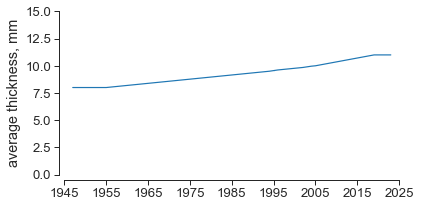

In [38]:
# Plot evolution of total glass thickness in IGUs:
fig, ax = plt.subplots(figsize=(6, 3))

sns.lineplot(data=df_eu_thick.reset_index(),
             x='year', y='average thickness, mm',
             ax=ax)

ax.yaxis.label.set_visible(True)
ax.xaxis.label.set_visible(False)
ax.set_xlim(1945, 2025)
ax.set_ylim(0, 15)
plt.xticks(np.arange(1945, 2026, 10))

sns.despine(offset=5)

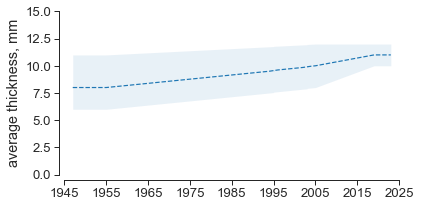

In [39]:
# Taking into acount uncertainty, with min. and max. average thickness
# Plot evolution of total glass thickness in IGUs w/ uncertainty:
df_toplot = df_eu_thick.reset_index('Nbr of countries').drop(
    labels='Nbr of countries', axis=1)

fig, ax = plt.subplots(figsize=(6, 3))

sns.lineplot(data=df_toplot['average thickness, mm'],
             linestyle='--', ax=ax)

ax.fill_between(df_toplot.index, df_toplot['max. thickness, mm'],
                df_toplot['min. thickness, mm'],
                alpha=0.10)

ax.yaxis.label.set_visible(True)
ax.xaxis.label.set_visible(False)
ax.set_xlim(1945, 2025)
ax.set_ylim(0, 15)
plt.xticks(np.arange(1945, 2026, 10))

sns.despine(offset=5)

In [40]:
levels = ['average', 'min.', 'max.']

In [41]:
# Adding columns for IGU flows in [kt],
# to be used later for material/energy/carbon intensity

for level in levels:
    for flow in ['Import', 'Export', 'Production']:
        df_eu[(f'{flow}', f'[kt], {level}')] = (
            df_eu[(f'{flow}', '[10^6 m²]')] *
            df_eu_thick[f'{level} thickness, mm'] * 2.5)

In [42]:
df_eu = df_eu.sort_index(axis=1)

## Production of Insulating Glass Units

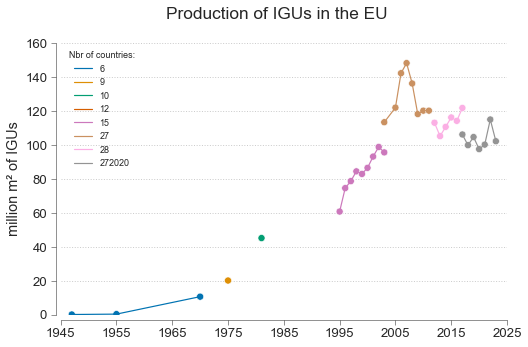

In [43]:
# Plot the European production of IGU
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['Production'].reset_index(),
             x='year', y='[10^6 m²]',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['Production'].reset_index(),
                x='year', y='[10^6 m²]',
                hue='Nbr of countries',
                palette='colorblind', s=50,
                ax=ax, legend=False)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)

plt.ylabel("million m² of IGUs")
plt.xticks(np.arange(1945, 2026, 10))

plt.legend(title='Nbr of countries:', frameon=False)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
style_ax(ax)

fig.suptitle('Production of IGUs in the EU')

sns.despine(offset=5)
plt.show()

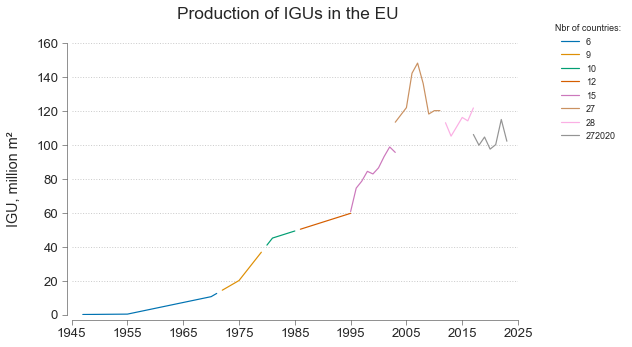

In [44]:
# Interpolation and plot the European production of IGU:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=(df_eu['Production']
                   .interpolate(method='linear').reset_index()),
             x='year', y='[10^6 m²]',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)
plt.xticks(np.arange(1945, 2026, 10))

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
ax.set_ylabel("IGU, million m²", loc='center', labelpad=15)

plt.legend(title='Nbr of countries:', frameon=False,
           bbox_to_anchor=(1.25, 1.1)
           )

style_ax(ax)

fig.suptitle('Production of IGUs in the EU')

sns.despine(offset=5)
plt.show()

## Consumption of Insulating Glass Units

In [45]:
# Estimate the consumption of IGU in the EU:
df_eu = df_eu.stack(dropna=False)

df_eu['Consumption'] = (df_eu['Production']
                        + df_eu['Import']
                        - df_eu['Export']
                        )

df_eu = df_eu.unstack()

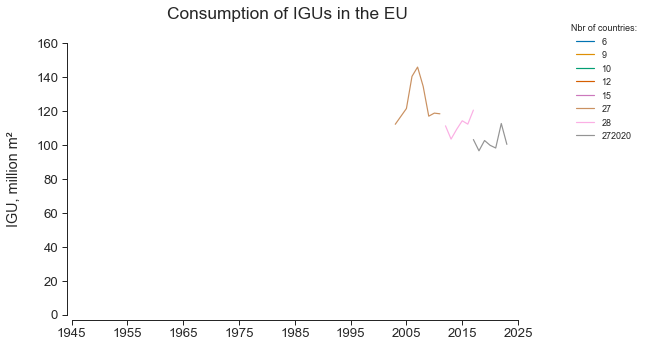

In [46]:
# Plot the European consumption of IGU:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['Consumption'].reset_index(),
             x='year', y='[10^6 m²]',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

ax.set_xlim(1950, 2025)
ax.set_ylim(0, 160)
plt.xticks(np.arange(1945, 2026, 10))

ax.legend(title='Nbr of countries:', frameon=False,
          bbox_to_anchor=(1.1, 1.1)
          )
ax.set_ylabel("IGU, million m²", loc='center', labelpad=15)
ax.set_xlabel('')

fig.suptitle('Consumption of IGUs in the EU')

sns.despine(offset=5)
plt.show()

## Summary

In [47]:
# Assess the annual growth:
df_eu[('Growth, production', '[%]')] = df_eu[(
    'Production', '[10^6 m²]')].interpolate().pct_change()

In [48]:
n_countries = df_eu.index.get_level_values(0).unique()

for i, start_n_countries in enumerate(n_countries[:-1]):
    if start_n_countries < 10:
        continue
    end_n_countries = n_countries[i+1]
    start_year = df_eu.loc[start_n_countries].index.max()
    end_year = df_eu.loc[end_n_countries].index.max()
    a = df_eu.loc[start_n_countries:end_n_countries,
                  ('Growth, production', '[%]')].mean()*100

    print(
        f'Years {start_year}-{end_year} ({start_n_countries} to {end_n_countries} countries)')
    print(f'IGU production growth in EU: {a:.2f}%\n')
    print('')

Years 1985-1995 (10 to 12 countries)
IGU production growth in EU: 3.12%


Years 1995-2003 (12 to 15 countries)
IGU production growth in EU: 3.67%


Years 2003-2011 (15 to 27 countries)
IGU production growth in EU: 4.32%


Years 2011-2017 (27 to 28 countries)
IGU production growth in EU: 1.97%


Years 2017-2023 (28 to 272020 countries)
IGU production growth in EU: -0.94%




In [49]:
n_countries

Int64Index([6, 9, 10, 12, 15, 27, 28, 272020], dtype='int64', name='Nbr of countries')

In [50]:
# Key dates for the changes in the MFA scope, i.e. EU enlargement:
EU_KDATES = {'EU-6': 1957, 'EU-9': 1972, 'EU-12': 1986,
             'EU-15': 1995, 'EU-27': 2003, 'EU-28': 2012, 'EU-27_2020': 2017}

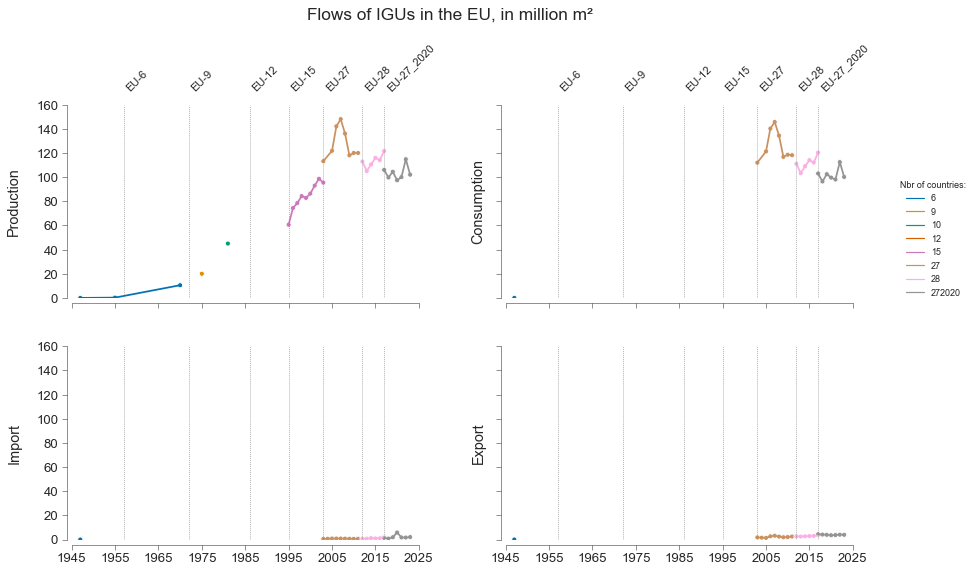

In [51]:
# Plot a synthesis of the results concerning European flows of IGU:
data1 = ['Production', 'Consumption']
data2 = ['Import', 'Export']

fig, axes = plt.subplots(nrows=2, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(14, 8))

# Plot production and consumption:
for col, data in enumerate(data1):
    ax = axes[0][col]
    sns.lineplot(data=df_eu[f"{data}"].reset_index(),
                 x='year', y="[10^6 m²]",
                 hue='Nbr of countries',
                 palette='colorblind', linewidth=1.75,
                 ax=ax)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)
        ax.text(x+0.25, 170, f"{y}", fontsize=11,
                verticalalignment='bottom', rotation=45)

    # Plot data gathered from literature review:
    sns.scatterplot(data=df_eu[f"{data}"].reset_index(),
                    x='year', y="[10^6 m²]",
                    hue='Nbr of countries',
                    palette='colorblind',
                    marker='.', s=100,
                    ax=ax, legend=False)

    ax.set_ylabel(f"{data}", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)
    ax.get_legend().remove()
    style_ax(ax)

# Plot import and export below:
for col, data in enumerate(data2):
    ax = axes[1][col]
    sns.lineplot(data=df_eu[f"{data}"].reset_index(),
                 x='year', y="[10^6 m²]",
                 hue='Nbr of countries',
                 palette='colorblind', linewidth=1.75,
                 ax=ax)

    # Plot data gathered from literature review:
    sns.scatterplot(data=df_eu[f"{data}"].reset_index(),
                    x='year', y="[10^6 m²]",
                    hue='Nbr of countries',
                    palette='colorblind',
                    marker='.', s=100,
                    ax=ax, legend=False)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)

    ax.set_ylabel(f"{data}", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)
    ax.get_legend().remove()
    style_ax(ax)

# Add legend:
plt.legend(title='Nbr of countries:', frameon=False,
           bbox_to_anchor=(1.35, 1.9), ncol=1
           )

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 161, 20))

fig.suptitle("Flows of IGUs in the EU, in million m²", y=1.05)
fig.subplots_adjust(wspace=0.25, hspace=0.25)

sns.despine(offset=5)
plt.show()

Hypothesis for missing data: EU production = EU consumption

In [52]:
df_eu = df_eu.stack(dropna=False)
df_eu['Estimated consumption'] = (df_eu['Consumption']
                                  .fillna(df_eu['Production']))

df_eu = df_eu.unstack()

In [53]:
# Number of countries for trend curves:
EU_COUNTRIES = [(6, 12), (15, 15), (27, 28), (272020, 272020)]

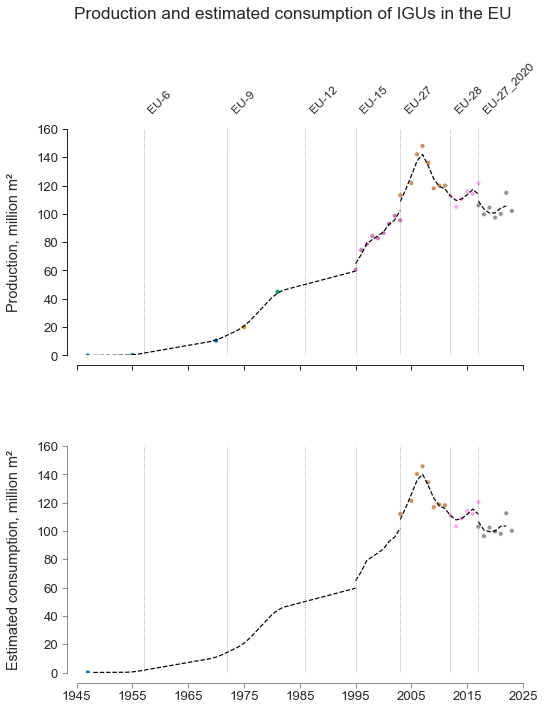

In [54]:
# Plot two figures:
fig, axes = plt.subplots(nrows=2, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(8, 10))

for row, data in enumerate(['Production', 'Estimated consumption']):
    for i, j in EU_COUNTRIES:
        ax = axes[row]
        # Plot the trend curve for IGU production:
        ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[i:j]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{data}", "[10^6 m²]")],
                c='black', linestyle='--')

        if row == 0:
            # Plot data gathered from literature review:
            sns.scatterplot(data=df_eu["Production"].reset_index(),
                            x='year', y="[10^6 m²]",
                            hue='Nbr of countries',
                            palette='colorblind',
                            marker='.', s=100,
                            ax=ax)

        else:
            # Plot data gathered from literature review:
            sns.scatterplot(data=df_eu["Consumption"].reset_index(),
                            x='year', y="[10^6 m²]",
                            hue='Nbr of countries',
                            palette='colorblind',
                            marker='.', s=100,
                            ax=ax)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)
        if row == 0:
            ax.text(x+0.5, 170, f"{y}", fontsize=12,
                    verticalalignment='bottom', rotation=45)

    ax.get_legend().remove()
    ax.set_ylabel(f"{data}, million m²", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)

style_ax(ax)
ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)

plt.xticks(np.arange(1945, 2026, 10))

plt.suptitle('Production and estimated consumption of IGUs in the EU',
             weight='light', y=1.05)

fig.subplots_adjust(hspace=0.40)

sns.despine(offset=10)
plt.show()

In [55]:
# Assess the annual growth:
df_eu[('Growth, consumption', '[%]')] = df_eu[(
    'Estimated consumption', '[10^6 m²]')].interpolate().pct_change()

In [56]:
n_countries = df_eu.index.get_level_values(0).unique()

for i, start_n_countries in enumerate(n_countries[:-1]):
    if start_n_countries < 10:
        continue
    end_n_countries = n_countries[i+1]
    start_year = df_eu.loc[start_n_countries].index.max()
    end_year = df_eu.loc[end_n_countries].index.max()
    a = df_eu.loc[start_n_countries:end_n_countries,
                  ('Growth, consumption', '[%]')].mean()*100

    print(
        f'Years {start_year}-{end_year} ({start_n_countries} to {end_n_countries} countries)')
    print(f'IGU consumption growth in EU: {a:.2f}%\n')
    print('')

Years 1985-1995 (10 to 12 countries)
IGU consumption growth in EU: 3.12%


Years 1995-2003 (12 to 15 countries)
IGU consumption growth in EU: 3.67%


Years 2003-2011 (15 to 27 countries)
IGU consumption growth in EU: 4.21%


Years 2011-2017 (27 to 28 countries)
IGU consumption growth in EU: 1.87%


Years 2017-2023 (28 to 272020 countries)
IGU consumption growth in EU: -0.95%




In [57]:
Y1 = (15, 1996)
Y2 = (15, 2003)

a = df_eu.loc[Y1:Y2, ('Growth, consumption', '[%]')].mean()*100

print(f'Nbr of countries, years: {Y1}-{Y2}')
print(f'IGU consumption growth in EU: {a:.2f}%\n')
print('')

Nbr of countries, years: (15, 1996)-(15, 2003)
IGU consumption growth in EU: 6.09%




In [58]:
# Peak of consumption:
Y_max = (df_eu[('Estimated consumption', '[10^6 m²]')].idxmax())
print("In year:")
print(Y_max)
print(df_eu[('Estimated consumption', '[10^6 m²]')].loc[Y_max].round(2))

In year:
(27, 2007)
145.66


In [59]:
# Data on production and consumption:
Y = (10, 1981)
print("In year:")
print(Y)
print(df_eu[('Estimated consumption', '[10^6 m²]')].loc[Y].round(2))

In year:
(10, 1981)
45.0


# Flows of IGU in France and Belgium

## Creating a Dataframe for the Flows of IGUs

In [60]:
# Create a DataFrame from production datasets:
df_fr_prod = raw_data.parse('Prod_FR').set_index('year')
df_be_prod = raw_data.parse('Prod_BE').set_index('year')

In [61]:
# Create DataFrames from import and export datasets:
df_fr_imp = raw_data.parse('Import_FR').set_index('year')
df_fr_exp = raw_data.parse('Export_FR').set_index('year')

df_be_imp = raw_data.parse('Import_BE').set_index('year')
df_be_exp = raw_data.parse('Export_BE').set_index('year')

In [62]:
# Create a DataFrame for the average thickness:
df_fr_thick = raw_data.parse('Thickness_FR').set_index('year')
df_be_thick = raw_data.parse('Thickness_BE').set_index('year')

In [63]:
# Create a DataFrame from consumption data, Belgium only:
df_fr_use = raw_data.parse('Consumption_FR').set_index('year')
df_be_use = raw_data.parse('Consumption_BE').set_index('year')

In [64]:
# Create a new DataFrame for Belgian and French IGU flows:
df_be_fr = (
    pd.concat([df_fr_use['IGU, "000 m²']/1000,
               df_fr_prod['IGU, "000 m²']/1000,
               df_fr_imp['IGU, "000 m²']/1000,
               df_fr_exp['IGU, "000 m²']/1000,
               df_be_use['IGU, kt'],
               df_be_use['IGU, "000 m²']/1000,
               df_be_prod['IGU, kt'],
               df_be_prod['IGU, "000 m²']/1000,
               df_be_imp['IGU, kt'],
               df_be_imp['IGU, "000 m²']/1000,
               df_be_exp['IGU, kt'],
               df_be_exp['IGU, "000 m²']/1000],
              axis=1,
              keys=[('Consumption', '[10^6 m²]', 'France'),
                    ('Production', '[10^6 m²]', 'France'),
                    ('Import', '[10^6 m²]', 'France'),
                    ('Export', '[10^6 m²]', 'France'),
                    ('Consumption', '[kt], average', 'Belgium'),
                    ('Consumption', '[10^6 m²]', 'Belgium'),
                    ('Production', '[kt], average', 'Belgium'),
                    ('Production', '[10^6 m²]', 'Belgium'),
                    ('Import', '[kt], average', 'Belgium'),
                    ('Import', '[10^6 m²]', 'Belgium'),
                    ('Export', '[kt], average', 'Belgium'),
                    ('Export', '[10^6 m²]', 'Belgium')],
              names=['Info', 'Unit', 'Country'])).stack(level=- 1,
                                                        dropna=False)

df_be_fr = df_be_fr.unstack()

In [65]:
# Create a DataFrame for the evolution of the population:
fr_pop = raw_data.parse('Population_FR').set_index('year')
be_pop = raw_data.parse('Population_BE').set_index('year')

In [66]:
# Create a unique DataFrame for French and Belgian population:
df_be_fr_pop = pd.concat([fr_pop['Population, x1000'],
                          be_pop['Population, x1000']],
                         axis=1, keys=[('Population [x1000]', 'France'),
                                       ('Population [x1000]', 'Belgium')],
                         names=['Info', 'Country']).stack()

df_be_fr_pop = df_be_fr_pop.unstack()

## Average Glass Thickness of IGUs

As the data are either in t or in m² depending on the year, we estimate the flows for each unit according to the evolution of the average thickness.

In [67]:
# Create a new DataFrame for average thickness, BE and FR:
df_be_fr_thick = (
    pd.concat([df_fr_thick['average thickness, mm'],
               df_be_thick['average thickness, mm'],
               df_fr_thick['min. thickness, mm'],
               df_be_thick['min. thickness, mm'],
               df_fr_thick['max. thickness, mm'],
               df_be_thick['max. thickness, mm']],
              axis=1,
              keys=[('average thickness, mm', 'France'),
                    ('average thickness, mm', 'Belgium'),
                    ('min. thickness, mm', 'France'),
                    ('min. thickness, mm', 'Belgium'),
                    ('max. thickness, mm', 'France'),
                    ('max. thickness, mm', 'Belgium')],
              names=['Info', 'Country'])).stack(dropna=False)

df_be_fr_thick = df_be_fr_thick.unstack()

In [68]:
# Linear interpolation for the average thickness:
df_be_fr_thick = df_be_fr_thick.interpolate(method='linear',
                                            limit_area='inside')

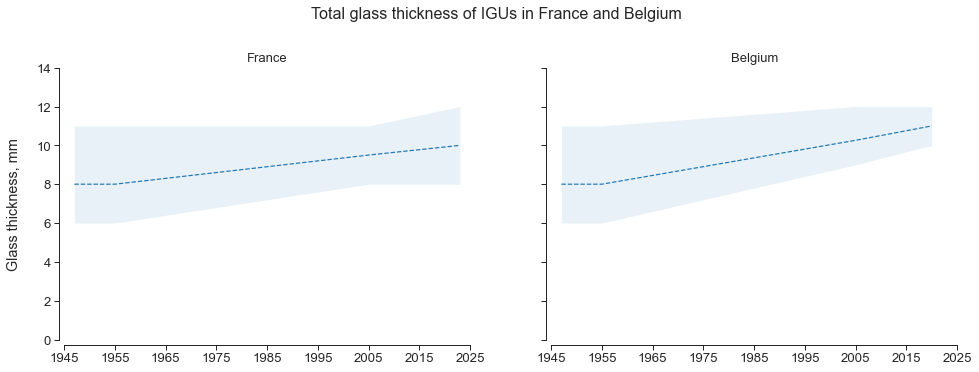

In [69]:
# Taking into acount uncertainty, with min. and max. average thickness:
# Plot evolution of total glass thickness of IGUs:
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(16, 5),
                         sharex=True, sharey=True)

for i, (ax, country) in enumerate(zip(axes.flatten(), countries)):
    sns.lineplot(data=df_be_fr_thick[('average thickness, mm', country)],
                 linestyle='--', ax=ax)

    ax.fill_between(df_be_fr_thick.index,
                    df_be_fr_thick[('max. thickness, mm', country)],
                    df_be_fr_thick[('min. thickness, mm', country)],
                    alpha=0.10)

    ax.set_title(country, fontsize=13)
    ax.set_ylabel("Glass thickness, mm", loc='center', labelpad=15)
    ax.xaxis.label.set_visible(False)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 14)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle('Total glass thickness of IGUs in France and Belgium',
             fontsize=16, y=1.05)

sns.despine(offset=5)

## Post-Processing the Flows of IGUs

Estimation of missing date:
- Production = consumption + export - import

- Consumption = production + import - export

In [70]:
# Estimation of missing data according to units available:
# Production:
df_be_fr['Production'] = (
    df_be_fr['Production'].fillna(
        df_be_fr['Consumption']+df_be_fr['Export']-df_be_fr['Import']))

# Consumption:
df_be_fr['Consumption'] = (
    df_be_fr['Consumption'].fillna(
        df_be_fr['Production'] + df_be_fr['Import']-df_be_fr['Export']))

df_be_fr = df_be_fr.sort_index(axis=1)

In [71]:
# Stock raw data in a new Dataframe:
df_be_fr_init = df_be_fr

For Belgium, the data is either in m², tonnes or both. To "harmonise" the time series, the missing values are estimated from the average thickness of glass per IGU:

In [72]:
flows = ['Consumption', 'Production', 'Export', 'Import']

In [73]:
# Estimation of total flows per m² according to values in kt:
for flow in flows:
    # Conditions for calculating missing data according to units available:
    has_kt = df_be_fr[(f'{flow}', '[kt], average', 'Belgium')].notna()
    has_m2 = df_be_fr[(f'{flow}', '[10^6 m²]', 'Belgium')].notna()

    # Calculating missing values flows according to thickness:
    df_be_fr.loc[has_kt & ~has_m2, (
        f'{flow}', '[10^6 m²]', 'Belgium')] = (
        df_be_fr.loc[has_kt & ~has_m2, (
            f'{flow}', '[kt], average', 'Belgium')]
        / df_be_fr_thick[('average thickness, mm', 'Belgium')] / 2.5)

In [74]:
# Estimation of total flows per kt according to values in m²:
for flow in flows:
    # Conditions for calculating missing data according to units available:
    has_kt = df_be_fr[(f'{flow}', '[kt], average', 'Belgium')].notna()
    has_m2 = df_be_fr[(f'{flow}', '[10^6 m²]', 'Belgium')].notna()

    # Calculating flows if missing according to thickness:
    df_be_fr.loc[has_m2 & ~has_kt, (
        f'{flow}', '[kt], average', 'Belgium')] = (
        df_be_fr.loc[has_m2 & ~has_kt, (
            f'{flow}', '[10^6 m²]', 'Belgium')]
        * df_be_fr_thick[('average thickness, mm', 'Belgium')] * 2.5)

In [75]:
# Estimation of missing data according to units available:
# Production:
df_be_fr['Production'] = (
    df_be_fr['Production'].fillna(
        df_be_fr['Consumption']+df_be_fr['Export']-df_be_fr['Import']))

# Consumption:
df_be_fr['Consumption'] = (
    df_be_fr['Consumption'].fillna(
        df_be_fr['Production'] + df_be_fr['Import']-df_be_fr['Export']))

df_be_fr = df_be_fr.sort_index(axis=1)

Taking into acount uncertainties regarding total glass thickness of the IGUs in Belgium:

In [76]:
for flow in flows:
    for level in ["min.", "max."]:
        df_be_fr[(f'{flow}', f'[kt], {level}', 'Belgium')] = (
            df_be_fr[(f'{flow}', '[10^6 m²]', 'Belgium')]
            * df_be_fr_thick[(f'{level} thickness, mm', 'Belgium')] * 2.5)

df_be_fr = df_be_fr.sort_index(axis=1)

Weighing the flows of IGUs, France (i.e. from Mm² to kt).
<br>
And taking into account uncertainties regarding the total glass thickness of the IGUs:

In [77]:
# Estimating total weight of the flows of IGUs [kt], France (raw data in m²)
# to be used later for material/energy/carbon intensity
for flow in flows:
    for level in levels:
        df_be_fr[(f'{flow}', f'[kt], {level}', 'France')] = (
            df_be_fr[(f'{flow}', '[10^6 m²]', 'France')]
            * df_be_fr_thick[(f'{level} thickness, mm', 'France')] * 2.5)

df_be_fr = df_be_fr.sort_index(axis=1)

## Production of Insulating Glass Units

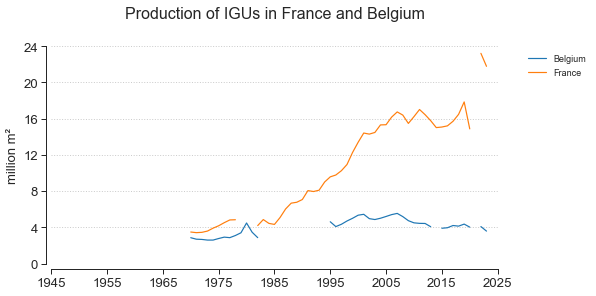

In [78]:
# Plot the BE and FR production of IGUs:
fig, ax = plt.subplots(figsize=(8, 4))

_ = df_be_fr[('Production', '[10^6 m²]')].plot(ax=ax)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_xlim(1945, 2025)
ax.set_xlabel(None)

plt.xticks(np.arange(1945, 2026, 10))

ax.set_ylim(0, 24)
plt.yticks(np.arange(0, 25, 4))
ax.set_ylabel('million m²', fontsize=13)

ax.set_title('Production of IGUs in France and Belgium', y=1.1, fontsize=16)

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

sns.despine(offset=5)

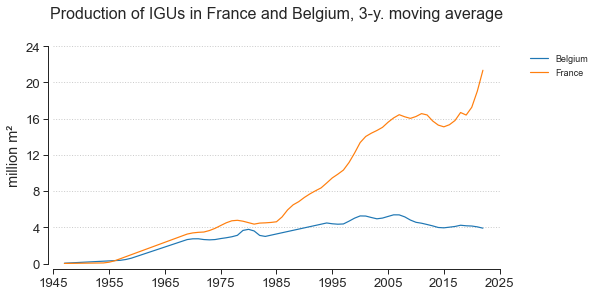

In [79]:
# Plot the moving average of the IGU production in BE and FR:
fig, ax = plt.subplots(figsize=(8, 4))

_ = df_be_fr[('Production', '[10^6 m²]')].interpolate(
    method="linear", limit_area='inside').rolling(
    3, center=True).mean().plot(ax=ax)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_xlabel(None)

ax.set_ylabel("million m²", loc='center')
ax.set_ylim(0, 24)
plt.yticks(np.arange(0, 25, 4))

ax.set_title('Production of IGUs in France and Belgium, 3-y. moving average',
             y=1.1, fontsize=16)

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

sns.despine(offset=5)

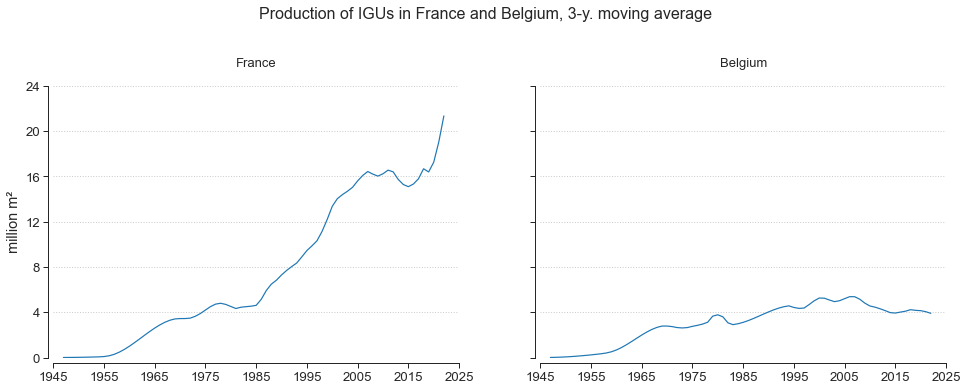

In [80]:
# Plot a moving average for IGU production:
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(16, 5),
                         sharex=True, sharey=True)

for i, (ax, country) in enumerate(zip(axes.flatten(), countries)):
    ax.plot(df_be_fr.index,
            df_be_fr[('Production', '[10^6 m²]')][country]
            # Linear interpolation for IGU production:
            .interpolate(method="pchip", limit_area='inside')
            # Rolling IGU production according to a 3-year mean:
            .rolling(3, center=True).mean())

    ax.set_title(country, fontsize=13, y=1.05)
    ax.set_xlim(1945, 2025)
    ax.set_ylim(0, 24)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    if i == 0:
        ax.set_ylabel("million m²", loc='center')

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 25, 4))

fig.suptitle("Production of IGUs in France and Belgium, 3-y. moving average",
             fontsize=16, y=1.1)

sns.despine(offset=5)
plt.show()

## Consumption of Insulating Glass Units

Text(0.5, 1.1, 'Consumption of IGUs in France and Belgium')

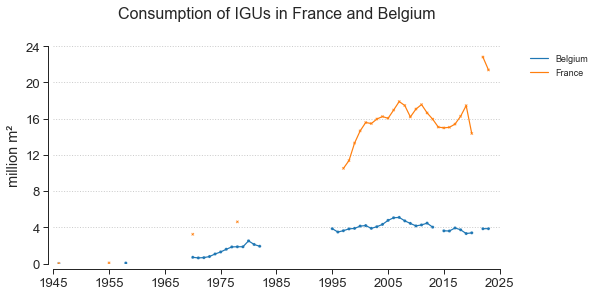

In [81]:
# Plot the BE and FR production of IGUs:
fig, ax = plt.subplots(figsize=(8, 4))

df_be_fr[('Consumption', '[10^6 m²]')].plot(ax=ax)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

sns.scatterplot(data=df_be_fr['Consumption', '[10^6 m²]'],
                marker='.', s=10, color='grey',
                ax=ax, legend=False)

ax.set_xlim(1945, 2025)
ax.set_xlabel(None)
ax.set_ylim(0, 24)
ax.set_ylabel("million m²", loc='center')

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 25, 4))

sns.despine(offset=5)
ax.set_title('Consumption of IGUs in France and Belgium', fontsize=16, y=1.1)

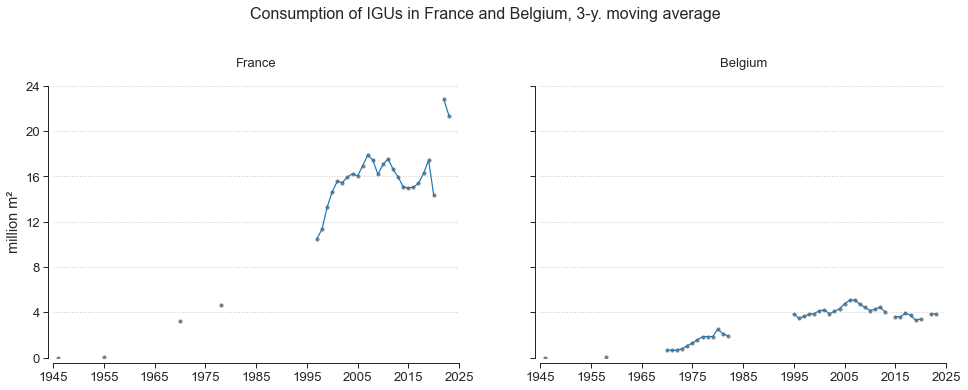

In [82]:
# Plot total consumption of IGU:
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(16, 5),
                         sharex=True, sharey=True)

for i, (ax, country) in enumerate(zip(axes.flatten(), countries)):
    ax.plot(df_be_fr.index,
            df_be_fr['Consumption', '[10^6 m²]'][country])
    ax.set_title(country, fontsize=13, y=1.05)
    sns.scatterplot(data=df_be_fr['Consumption', '[10^6 m²]'][country],
                    marker='.', s=100, color='grey',
                    ax=ax)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_ylabel("million m²", loc='center')
    ax.set_xlabel(None)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 24)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 25, 4))

fig.suptitle("Consumption of IGUs in France and Belgium, 3-y. moving average",
             fontsize=16, y=1.1)

sns.despine(offset=5)
plt.show()

Given the scarcity of data on the consumption of insulating glass units in France, and considering the low level of exports and imports over the study period, we assume that the production is roughly equivalent to the consumption when data is missing. Please refer to the article for a detailed discussion of this hypothesis.

In [83]:
# Estimation of missing data relating to the consumption of IGU:
for unit in ['[kt], average', '[kt], max.', '[kt], min.', '[10^6 m²]']:
    df_be_fr['Consumption', unit, 'France'] = (
        df_be_fr['Consumption', unit, 'France'].fillna(
            df_be_fr['Production', unit, 'France']))

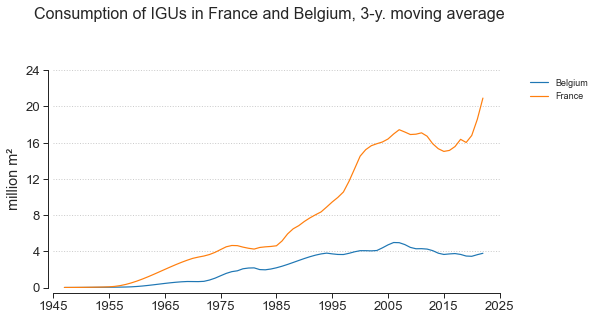

In [84]:
# Linear interpolation for IGU consumption
# and moving average with a 3-year window length:
fig, ax = plt.subplots(figsize=(8, 4))

_ = (df_be_fr[('Consumption', '[10^6 m²]')]
     .interpolate(method="pchip", limit_area='inside')
     .rolling(3, center=True).mean().plot(ax=ax))

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_xlim(1945, 2025)
ax.set_xlabel(None)
ax.set_ylim(0, 24)
ax.set_ylabel("million m²")

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 26, 4))

fig.suptitle("Consumption of IGUs in France and Belgium, 3-y. moving average",
             fontsize=16, y=1.1)

sns.despine(offset=5)

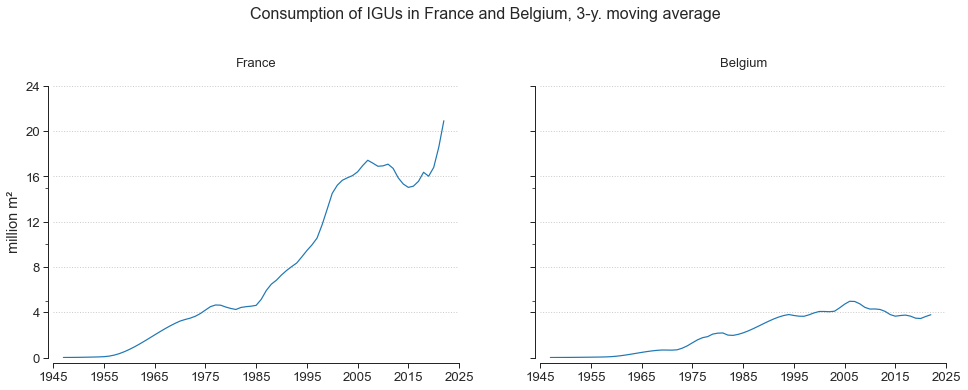

In [85]:
# Linear interpolation for IGU consumption
# and moving average with a 3-year window length:
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(16, 5),
                         sharex=True, sharey=True)

for i, (ax, country) in enumerate(zip(axes.flatten(), countries)):
    (df_be_fr['Consumption', '[10^6 m²]'][country]
     .interpolate(method="pchip", limit_area='inside')
     .rolling(3, center=True).mean()).plot(ax=ax)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_title(country, fontsize=13, y=1.05)
    ax.set_ylabel("million m²", loc='center')
    ax.set_xlabel(None)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 20)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 26, 4))

fig.suptitle("Consumption of IGUs in France and Belgium, 3-y. moving average",
             fontsize=16, y=1.1)

sns.despine(offset=5)
plt.show()

Estimation of the consumption of IGU per capita in BE and FR:

In [86]:
# Estimating the IGU consumption per capita
for country in countries:
    df_be_fr[('Consumption', '[m²/1000cap]', country)] = (
        df_be_fr[('Consumption', '[10^6 m²]', country)]
        .interpolate(method='pchip', limit_area="inside")*1000
        / df_be_fr_pop[('Population [x1000]', country)]
        .interpolate(method='pchip', limit_area="inside"))*1000

df_be_fr = df_be_fr.sort_index(axis=1)

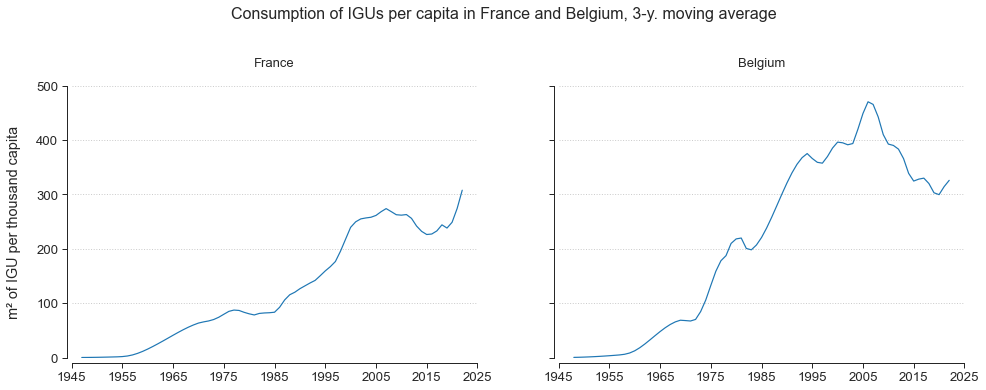

In [87]:
# Linear interpolation for IGU consumption per capita
# and moving average with a 3-y. window length:
fig, axes = plt.subplots(nrows=1, ncols=2,
                         figsize=(16, 5),
                         sharex=True, sharey=True)

for i, (ax, country) in enumerate(zip(axes.flatten(), countries)):
    (df_be_fr['Consumption', '[m²/1000cap]'][country]
     .interpolate(method="pchip", limit_area='inside')
     .rolling(3, center=True).mean()).plot(ax=ax)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_title(country, fontsize=13, y=1.05)
    ax.set_xlim(1945, 2025)
    ax.set_ylim(0, 500)

    ax.set_ylabel("m² of IGU per thousand capita", labelpad=15)
    ax.set_xlabel(None)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Consumption of IGUs per capita in France and Belgium,"
             " 3-y. moving average",
             fontsize=16, y=1.1)

sns.despine(offset=5)
plt.show()

## Summary

In [88]:
df_be_fr['Consumption'].describe()

Unit    [10^6 m²]        [kt], average         [kt], max.         [kt], min.  \
Country   Belgium France       Belgium  France    Belgium  France    Belgium   
count       42.00  52.00         39.00   51.00      39.00   51.00      39.00   
mean         3.05  10.67         78.38  257.41      91.63  306.37      68.44   
std          1.48   5.97         39.13  146.32      43.83  169.55      35.40   
min          0.00   0.00          1.02    1.29       1.38    1.77       0.77   
25%          1.85   4.76         41.91  105.63      53.05  132.78      34.27   
50%          3.67  10.13         95.02  242.97     108.25  288.63      83.67   
75%          4.11  15.96        106.60  382.31     123.61  447.49      95.82   
max          5.09  22.79        131.69  568.09     152.55  680.44     116.11   

Unit            [m²/1000cap]          
Country  France      Belgium  France  
count     51.00        77.00   78.00  
mean     211.47       216.06  126.50  
std      121.03       158.34  100.90  
min        0.97         0.05    0.00  
25%       84.51        54.95   42.29  
50%      201.51       237.22   89.50  
75%      319.49       356.72  229.75  
max      455.74       478.73  335.46

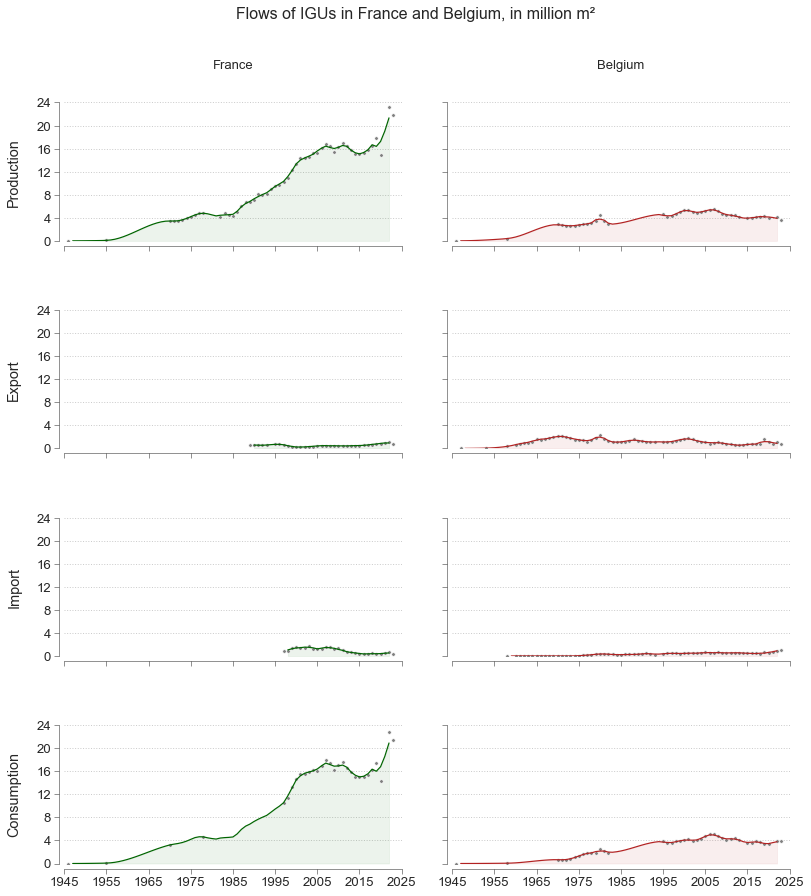

In [89]:
# Plot total flows, moving average w/ a 3-y. window length:
toplot = ['Production', 'Export', 'Import', 'Consumption']
nrows = len(toplot)
ncols = len(countries)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         sharex=True, sharey=True,
                         figsize=(13, 14))

for row, data in enumerate(toplot):
    for col, country in enumerate(countries):
        ax = axes[row][col]
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        (df_be_fr[(data, "[10^6 m²]", country)]
         .interpolate(method="pchip", limit_area='inside')
         .rolling(3, center=True).mean()
         .plot(ax=ax, c=color)
         )

        x = df_be_fr.index
        y = (df_be_fr[(data, "[10^6 m²]", country)]
             .interpolate(method="pchip", limit_area='inside')
             .rolling(3, center=True).mean())
        ax.fill_between(x, y, color=color, alpha=0.075)

        # Plot raw data:
        sns.scatterplot(data=df_be_fr_init[data, "[10^6 m²]"][country],
                        marker='.', s=50, color='grey',
                        ax=ax)

        ax.get_legend().remove()
        ax.set_ylabel(f"{data}", loc='center', labelpad=15)
        ax.minorticks_off()
        ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
        style_ax(ax)

        if row == 0:
            ax.set_title(country, fontsize=13, y=1.2)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 24)
plt.yticks(np.arange(0, 26, 4))

fig.subplots_adjust(wspace=0.15, hspace=0.5)

fig.suptitle("Flows of IGUs in France and Belgium, in million m²",
             fontsize=16, y=0.975)

sns.despine(offset=5)

plt.show()

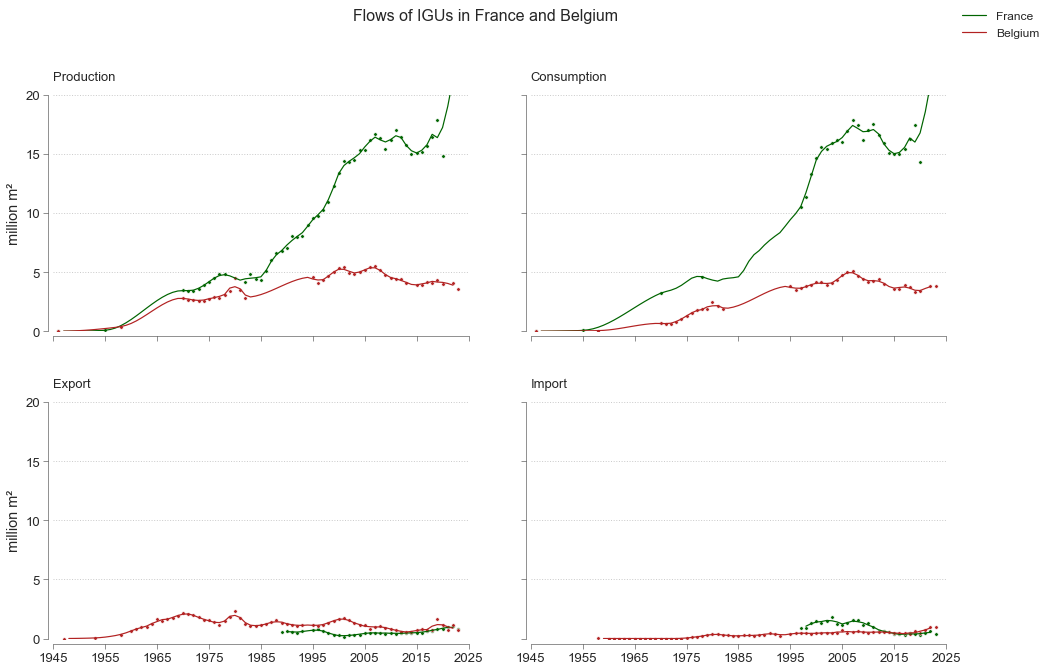

In [90]:
# Plot total flows, moving average w/ a 3-y. window length:
toplot = ['Production', 'Export', 'Import', 'Consumption']

fig, axes = plt.subplots(nrows=2, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(16, 10))

for data in toplot:
    if data == "Production":
        ax = axes[0][0]
    if data == "Consumption":
        ax = axes[0][1]
    if data == "Export":
        ax = axes[1][0]
    if data == "Import":
        ax = axes[1][1]

    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
            ax.set_title(f"{data}", loc='left', pad=15, fontsize=13)
        else:
            color = 'darkgreen'

        (df_be_fr[(data, "[10^6 m²]", country)]
         .interpolate(method="pchip", limit_area='inside')
         .rolling(3, center=True).mean()
         .plot(ax=ax, c=color)
         )

        # Plot raw data:
        sns.scatterplot(data=df_be_fr_init[data, "[10^6 m²]", country],
                        marker='.', s=50, color=color, ax=ax)

        ax.get_legend().remove()

        ax.minorticks_off()
        ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
        style_ax(ax)
        ax.set_ylabel("million m²")

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 20)
plt.yticks(np.arange(0, 21, 5))

fig.subplots_adjust(wspace=0.15, hspace=0.3)

# Add legend:
plt.legend(countries, frameon=False, bbox_to_anchor=(1.25, 2.7),
           ncol=1, fontsize=12)

fig.suptitle("Flows of IGUs in France and Belgium", fontsize=16, y=1)
sns.despine(offset=5)

plt.show()

In [91]:
# Assess the annual growth:
for country in countries:
    df_be_fr[('Growth, consumption', '[%]', country)] = df_be_fr[(
        'Consumption', '[10^6 m²]', country)].interpolate().pct_change()

In [92]:
Y1 = 1985
Y2 = 2007

print(f'Years: {Y1}-{Y2}')
for country in countries:
    a = df_be_fr.loc[Y1:Y2, ('Growth, consumption', '[%]',
                             country)].mean()*100
    print(f'IGU consumption growth in {country}: {a:.2f}%\n')

Years: 1985-2007
IGU consumption growth in France: 6.43%

IGU consumption growth in Belgium: 3.81%



In [93]:
# Peak of consumption:
for country in countries:
    Y_max = (
        df_be_fr[('Consumption', '[10^6 m²]', country)].idxmax())
    print(f"Peak in {country} in year: {Y_max}")
    print(df_be_fr[('Consumption',
          '[10^6 m²]', country)].loc[Y_max].round(2), "million m²", "\n")

Peak in France in year: 2022
22.79 million m² 

Peak in Belgium in year: 2007
5.09 million m² 



In [94]:
# Data on consumption:
Y = 2007
print(f"In year: {Y}\n")
for country in countries:
    print(f"Consumption in {country}:", "\n",
          df_be_fr[('Consumption', '[10^6 m²]', country)].loc[Y].round(2),
          "million m²", "\n",
          df_be_fr[('Consumption', '[m²/1000cap]', country)].loc[Y].round(2),
          "m²/1000cap", "\n")

In year: 2007

Consumption in France: 
 17.88 million m² 
 281.07 m²/1000cap 

Consumption in Belgium: 
 5.09 million m² 
 478.55 m²/1000cap 



# The European Production of IGU: Environmental Analysis

## Use of Raw Materials

In [95]:
# Absolute use of raw materials for IGU production:
for mat in materials:
    for level in levels:
        df_eu[(f"{mat}, production", f"[kt], {level}")] = (
            df_eu[('Production', f"[kt], {level}")]
            * (df_rawmat[(f"{mat}, kg/kg")]
               .interpolate(method='pchip', limit_direction='forward'))
        )

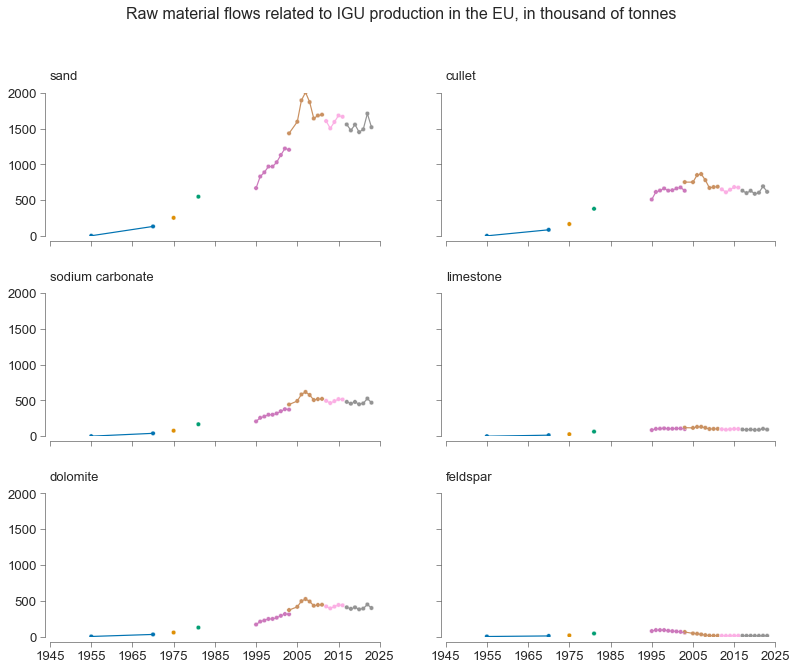

In [96]:
# Plot raw material flows for IGU production in the EU:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    sns.lineplot(data=df_eu[f"{mat}, production"].reset_index(),
                 x='year', y='[kt], average',
                 hue='Nbr of countries',
                 palette='colorblind',
                 ax=ax)

    sns.scatterplot(data=df_eu[f"{mat}, production"].reset_index(),
                    x='year', y='[kt], average',
                    hue='Nbr of countries',
                    palette='colorblind', s=20,
                    ax=ax)

    ax.set_title(mat, loc='left', fontsize=13, y=1.05)
    ax.set_ylabel(None)
    style_ax(ax)
    ax.get_legend().remove()

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 2000)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Raw material flows related to IGU production in the EU, "
             "in thousand of tonnes",
             fontsize=16, y=1)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

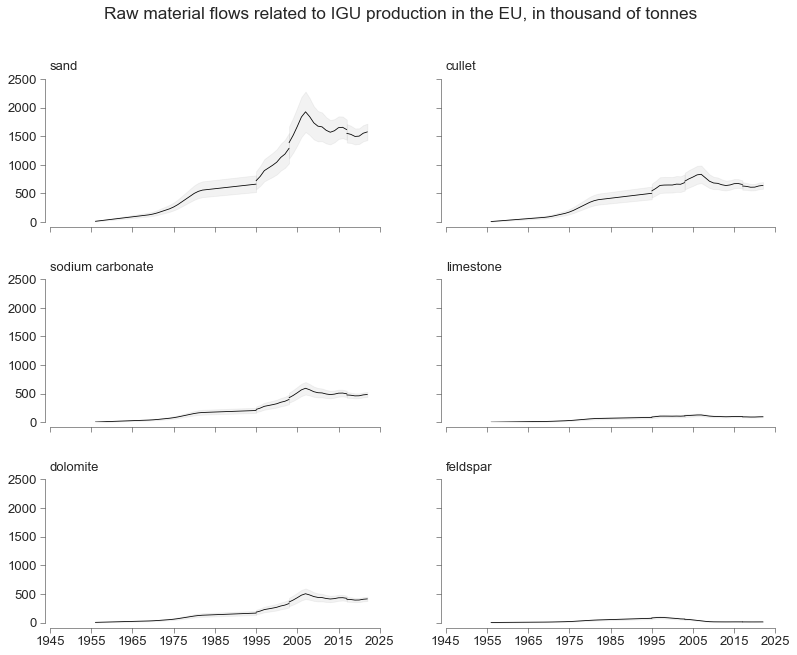

In [97]:
# Plot raw material flows for IGU production:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate()
                .rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{mat}, production", '[kt], average')],
                linewidth=0.8, c='black', linestyle='-'
                )

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, production", '[kt], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, production", '[kt], min.')],
                        alpha=0.10, color='grey')

        ax.set_title(mat, loc='left', fontsize=13, y=1.02)
        style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 2500)
plt.yticks(np.arange(0, 2501, 500))

fig.suptitle("Raw material flows related to IGU production in the EU,"
             " in thousand of tonnes")
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)

plt.show()

In [98]:
# Estimate total use of raw materials (sum per material):
for level in levels:
    df_eu[('Total raw materials, production', f'[Mt], {level}')] = 0

for level in levels:
    for mat in materials:
        df_eu[('Total raw materials, production', f'[Mt], {level}')] = (
            df_eu[(f"{mat}, production", f'[kt], {level}')]/1000
            + df_eu[('Total raw materials, production', f'[Mt], {level}')]
        )

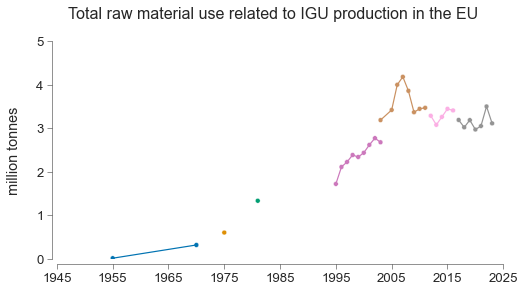

In [99]:
# Plot total material use for IGU production in the EU:
fig, ax = plt.subplots(figsize=(8, 4))

sns.lineplot(data=df_eu['Total raw materials, production'].reset_index(),
             x='year', y='[Mt], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['Total raw materials, production'].reset_index(),
                x='year', y='[Mt], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 5)
ax.set_ylabel("million tonnes", labelpad=15)
style_ax(ax)
ax.get_legend().remove()

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total raw material use related to IGU production in the EU",
             fontsize=16, y=1)

sns.despine(offset=5)
plt.show()

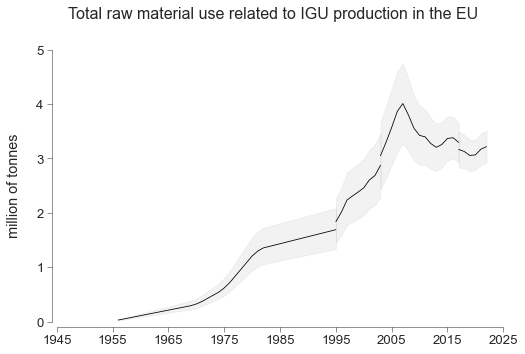

In [100]:
# Plot total material use for IGU production in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total raw materials, production', '[Mt], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total raw materials, production', '[Mt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total raw materials, production', '[Mt], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 5)
ax.set_ylabel("million of tonnes", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total raw material use related to IGU production in the EU",
             fontsize=16, y=1)

sns.despine(offset=5)
plt.show()

## Energy Use

In [101]:
# Absolute use of energy for IGU production:
for energy in energies:
    for level in levels:
        df_eu[(f"{energy}, production", f"[PJ], {level}")] = (
            df_eu[('Production', f"[kt], {level}")]
            * (df_eu_energy[f"{energy}, GJ/t"]
               .interpolate(method='pchip', limit_direction='forward'))/1000
        )

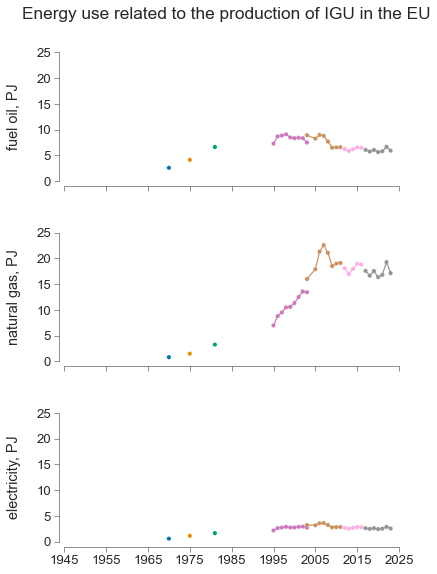

In [102]:
# Plot energy used for IGU production in EU:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    sns.lineplot(data=df_eu[f"{energy}, production"].reset_index(),
                 x='year', y='[PJ], average',
                 hue='Nbr of countries',
                 palette='colorblind',
                 ax=ax)

    sns.scatterplot(data=df_eu[f"{energy}, production"].reset_index(),
                    x='year', y='[PJ], average',
                    hue='Nbr of countries',
                    palette='colorblind', s=20,
                    ax=ax)

    ax.set_ylabel(f"{energy}, PJ", labelpad=15)
    style_ax(ax)
    ax.get_legend().remove()

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 25)
plt.yticks(np.arange(0, 26, 5))

fig.suptitle("Energy use related to the production of IGU in the EU", y=0.95)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

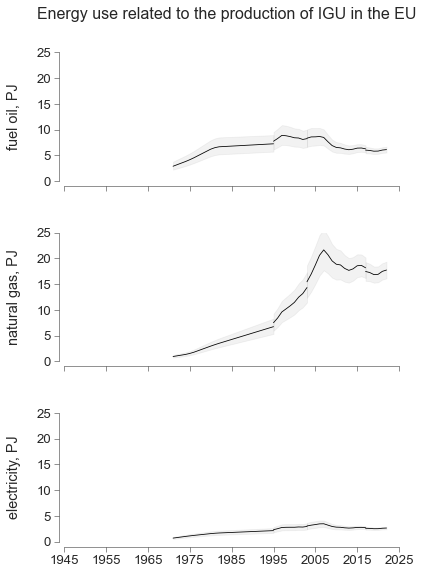

In [103]:
# Plot energy flows for IGU production, 3-y rolled:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate()
                .rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{energy}, production", '[PJ], average')],
                linewidth=0.8, c='black', linestyle='-'
                )

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, production", '[PJ], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, production", '[PJ], min.')],
                        alpha=0.10, color='grey')

        ax.set_ylabel(f"{energy}, PJ", labelpad=15)
        style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 25)
plt.yticks(np.arange(0, 26, 5))

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Energy use related to the production of IGU in the EU",
             y=0.95, fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [104]:
# Estimate total energy use (sum per energy type):
for level in levels:
    df_eu[('Total energy, production', f'[PJ], {level}')] = 0

for level in levels:
    for energy in energies:
        df_eu[('Total energy, production', f'[PJ], {level}')] = (
            df_eu[(f"{energy}, production", f'[PJ], {level}')]
            + df_eu[('Total energy, production', f'[PJ], {level}')]
        )

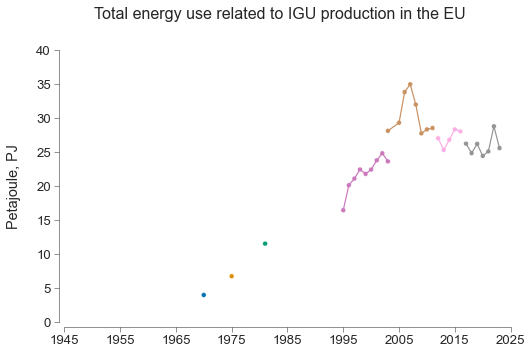

In [105]:
# Plot total energy use for IGU production in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['Total energy, production'].reset_index(),
             x='year', y='[PJ], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['Total energy, production'].reset_index(),
                x='year', y='[PJ], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 40)
ax.get_legend().remove()
ax.set_ylabel("Petajoule, PJ", labelpad=15)
style_ax(ax)

fig.suptitle("Total energy use related to IGU production in the EU",
             fontsize=16, y=1)
fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)
plt.show()

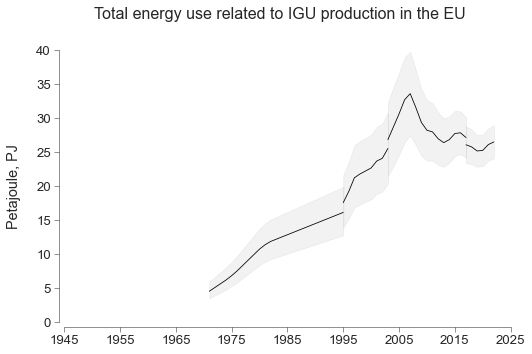

In [106]:
# Plot total energy use for IGU production in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total energy, production', '[PJ], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total energy, production', '[PJ], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total energy, production', '[PJ], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 40)
ax.set_ylabel("Petajoule, PJ", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total energy use related to IGU production in the EU",
             fontsize=16, y=1)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Absolute CO2 Emissions

In [107]:
# Estimating the co2 emission related to IGU production:
for level in levels:
    df_eu[("co2, production", f"[kt], {level}")] = (
        df_eu[('Production', f"[kt], {level}")]
        * df_eu_co2['CO2 interpolated [kg/t]'] / 1000
    )

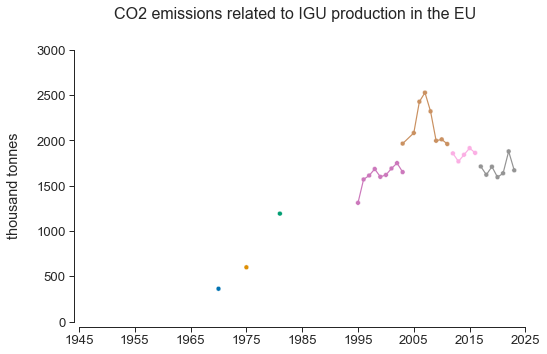

In [108]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['co2, production'].reset_index(),
             x='year', y='[kt], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['co2, production'].reset_index(),
                x='year', y='[kt], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
ax.set_xlabel(None)
ax.set_ylabel("thousand tonnes", labelpad=15)
ax.get_legend().remove()

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 3001, 500))

fig.suptitle("CO2 emissions related to IGU production in the EU",
             fontsize=16, y=1)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

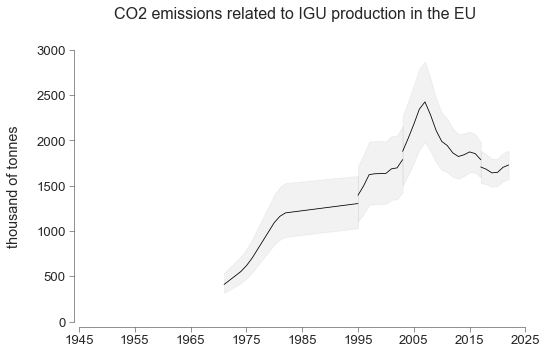

In [109]:
# Plot total co2 emissions for IGU production in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('co2, production', '[kt], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, production', '[kt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, production', '[kt], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 3000)
ax.set_ylabel("thousand of tonnes", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("CO2 emissions related to IGU production in the EU",
             fontsize=16, y=1)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

# The European Consumption of IGU: Environmental Analysis

## Use of Raw Materials

In [110]:
# Absolute use of raw materials for IGU consumption:
for mat in materials:
    for level in levels:
        df_eu[(f"{mat}, consumption", f"[kt], {level}")] = (
            df_eu[('Estimated consumption', f"[kt], {level}")]
            * (df_rawmat[(f"{mat}, kg/kg")]
               .interpolate(method='pchip', limit_direction='forward'))
        )

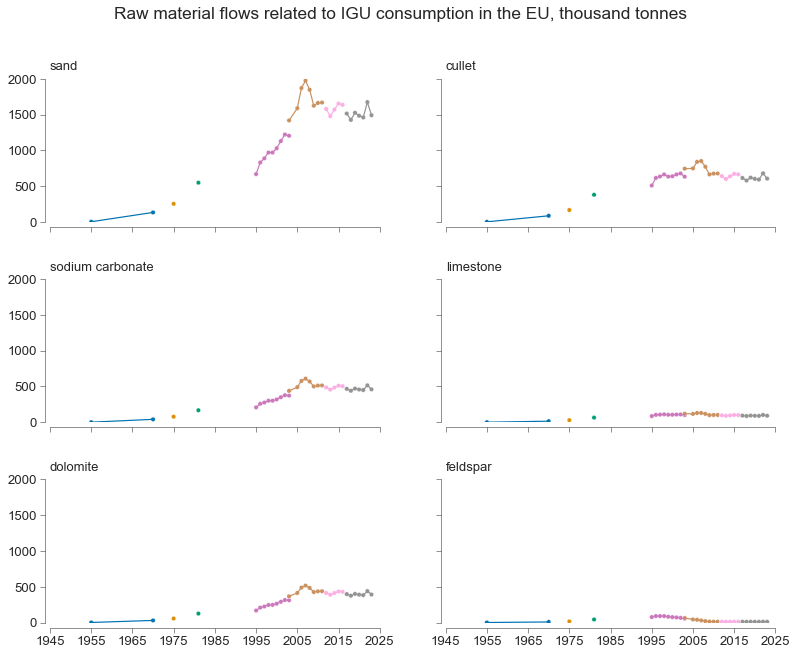

In [111]:
# Plot raw material flows for IGU consumption in the EU:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    sns.lineplot(data=df_eu[f"{mat}, consumption"].reset_index(),
                 x='year', y='[kt], average',
                 hue='Nbr of countries',
                 palette='colorblind',
                 ax=ax)

    sns.scatterplot(data=df_eu[f"{mat}, consumption"].reset_index(),
                    x='year', y='[kt], average',
                    hue='Nbr of countries',
                    palette='colorblind', s=20,
                    ax=ax)

    ax.set_title(mat, loc='left', fontsize=13, y=1.02)
    ax.set_ylabel(None)
    style_ax(ax)
    ax.get_legend().remove()

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 2000)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Raw material flows related to IGU consumption in the EU, "
             "thousand tonnes")
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

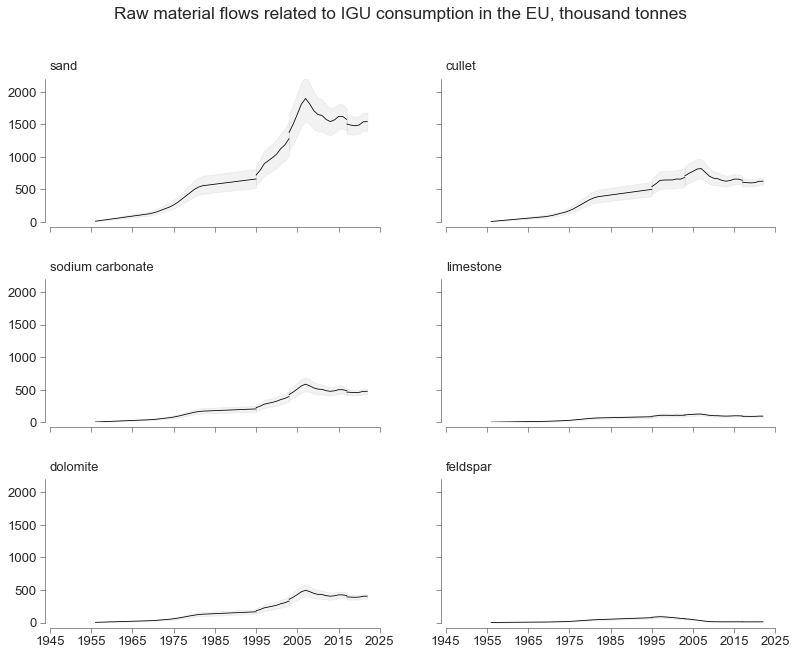

In [112]:
# Plot raw material flows for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate()
                .rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{mat}, consumption", '[kt], average')],
                linewidth=0.8, c='black', linestyle='-'
                )

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, consumption", '[kt], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, consumption", '[kt], min.')],
                        alpha=0.10, color='grey')

        ax.set_title(mat, loc='left', fontsize=13, y=1.02)
        style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 2200)
plt.yticks(np.arange(0, 2201, 500))

fig.suptitle("Raw material flows related to IGU consumption in the EU, "
             "thousand tonnes")

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [113]:
# Estimate total use of raw materials (sum per material):
for level in levels:
    df_eu[('Total raw materials, consumption', f'[Mt], {level}')] = 0

for level in levels:
    for mat in materials:
        df_eu[('Total raw materials, consumption', f'[Mt], {level}')] = (
            df_eu[(f"{mat}, consumption", f'[kt], {level}')]/1000
            + df_eu[('Total raw materials, consumption', f'[Mt], {level}')]
        )

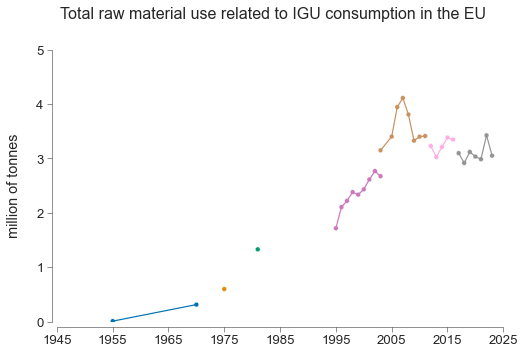

In [114]:
# Plot total material use for IGU consumption in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['Total raw materials, consumption'].reset_index(),
             x='year', y='[Mt], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['Total raw materials, consumption'].reset_index(),
                x='year', y='[Mt], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 5)
ax.set_ylabel("million of tonnes", labelpad=15)
style_ax(ax)
ax.get_legend().remove()

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total raw material use related to IGU consumption in the EU",
             fontsize=16, y=1)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)

plt.show()

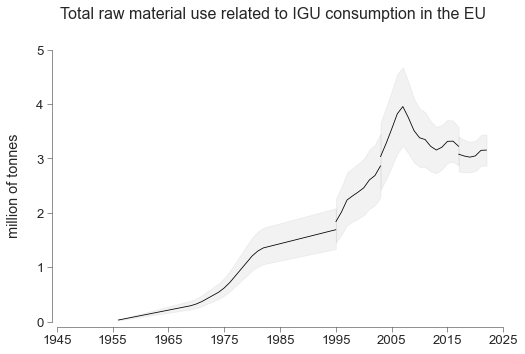

In [115]:
# Plot total material use for IGU consumption in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total raw materials, consumption', '[Mt], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total raw materials, consumption', '[Mt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total raw materials, consumption', '[Mt], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 5)
ax.set_ylabel("million of tonnes", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total raw material use related to IGU consumption in the EU",
             fontsize=16, y=1)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Energy Use

In [116]:
# Absolute use of energy for IGU consumption:
for energy in energies:
    for level in levels:
        df_eu[(f"{energy}, consumption", f"[PJ], {level}")] = (
            df_eu[('Estimated consumption', f"[kt], {level}")]
            * (df_eu_energy[f"{energy}, GJ/t"]
               .interpolate(method='pchip', limit_direction='forward'))/1000
        )

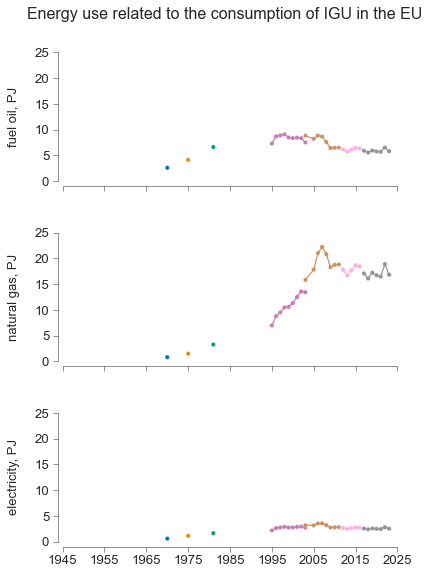

In [117]:
# Plot energy used for IGU consumption in EU:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    sns.lineplot(data=df_eu[f"{energy}, consumption"].reset_index(),
                 x='year', y='[PJ], average',
                 hue='Nbr of countries',
                 palette='colorblind',
                 ax=ax)

    sns.scatterplot(data=df_eu[f"{energy}, consumption"].reset_index(),
                    x='year', y='[PJ], average',
                    hue='Nbr of countries',
                    palette='colorblind', s=20,
                    ax=ax)

    ax.set_ylabel(f"{energy}, PJ", labelpad=15, fontsize=13)
    style_ax(ax)
    ax.get_legend().remove()

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 25)

plt.yticks(np.arange(0, 26, 5))
plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Energy use related to the consumption of IGU in the EU",
             y=0.95, fontsize=16)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

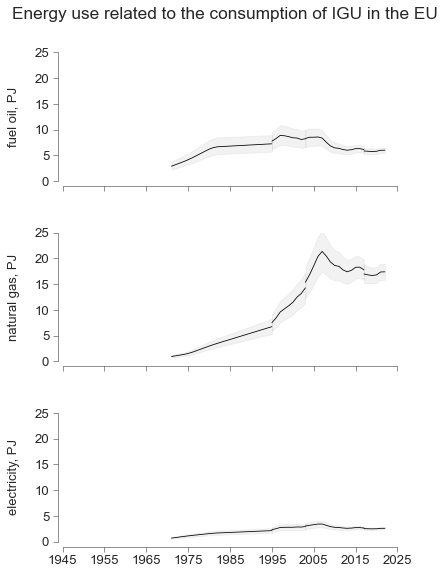

In [118]:
# Plot energy flows for IGU consumption, 5-y rolled:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate()
                .rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{energy}, consumption", '[PJ], average')],
                linewidth=0.8, c='black', linestyle='-'
                )

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, consumption", '[PJ], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, consumption", '[PJ], min.')],
                        alpha=0.10, color='grey')

        ax.set_ylabel(f"{energy}, PJ", labelpad=15, fontsize=13)
        style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 25)
plt.yticks(np.arange(0, 26, 5))

fig.suptitle("Energy use related to the consumption of IGU in the EU",
             y=0.95)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [119]:
# Estimate total energy use (sum per energy type):
for level in levels:
    df_eu[('Total energy, consumption', f'[PJ], {level}')] = 0

for level in levels:
    for energy in energies:
        df_eu[('Total energy, consumption', f'[PJ], {level}')] = (
            df_eu[(f"{energy}, consumption", f'[PJ], {level}')]
            + df_eu[('Total energy, consumption', f'[PJ], {level}')]
        )

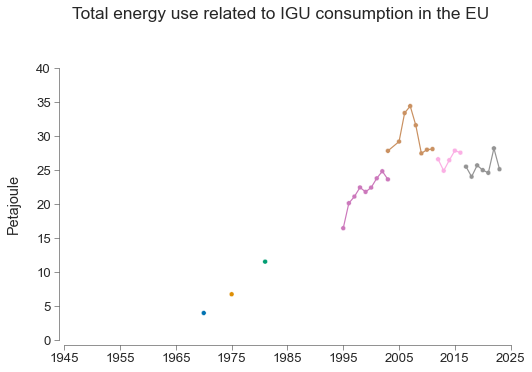

In [120]:
# Plot total energy use for IGU consumption in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['Total energy, consumption'].reset_index(),
             x='year', y='[PJ], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['Total energy, consumption'].reset_index(),
                x='year', y='[PJ], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 40)
ax.get_legend().remove()
ax.set_ylabel("Petajoule", labelpad=15)
style_ax(ax)

fig.suptitle("Total energy use related to IGU consumption in the EU", y=1.05)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

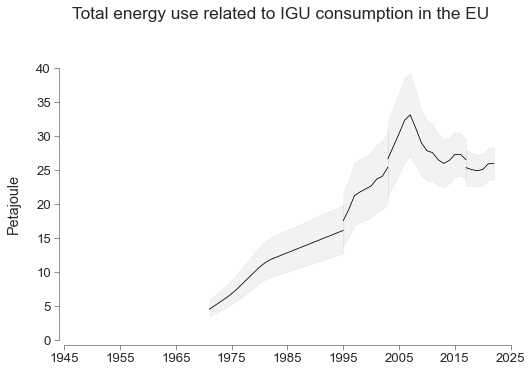

In [121]:
# Plot total energy use for IGU consumption in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total energy, consumption', '[PJ], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total energy, consumption', '[PJ], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('Total energy, consumption', '[PJ], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 40)
ax.set_ylabel("Petajoule", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total energy use related to IGU consumption in the EU", y=1.05)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Absolute CO2 Emissions

In [122]:
# Estimating the co2 emission related to IGU consumption:
for level in levels:
    df_eu[("co2, consumption", f"[kt], {level}")] = (
        df_eu[('Estimated consumption', f"[kt], {level}")]
        * df_eu_co2['CO2 interpolated [kg/t]'] / 1000
    )

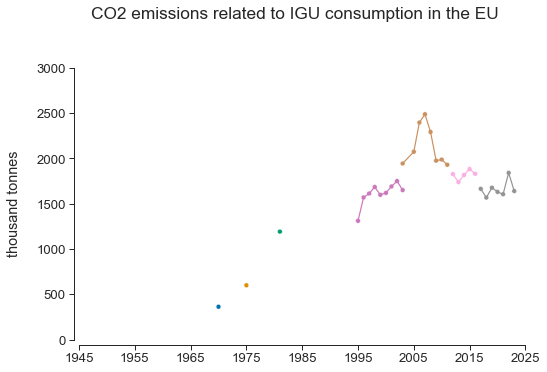

In [123]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(data=df_eu['co2, consumption'].reset_index(),
             x='year', y='[kt], average',
             hue='Nbr of countries',
             palette='colorblind',
             ax=ax)

sns.scatterplot(data=df_eu['co2, consumption'].reset_index(),
                x='year', y='[kt], average',
                hue='Nbr of countries',
                palette='colorblind',
                ax=ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 3000)
ax.get_legend().remove()
ax.set_ylabel("thousand tonnes", labelpad=15)
ax.set_xlabel(None)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("CO2 emissions related to IGU consumption in the EU", y=1.05)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

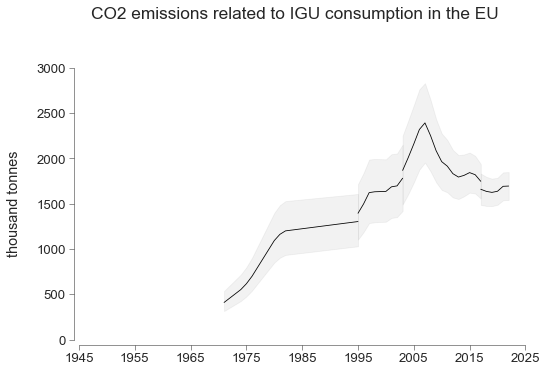

In [124]:
# Plot total co2 emissions for IGU consumption in the EU:
fig, ax = plt.subplots(figsize=(8, 5))

for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean()
            .loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('co2, consumption', '[kt], average')],
            linewidth=0.8, c='black', linestyle='-'
            )

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], min.')],
                    alpha=0.10, color='grey')

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 3000)
ax.set_ylabel("thousand tonnes", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("CO2 emissions related to IGU consumption in the EU", y=1.05)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Summary

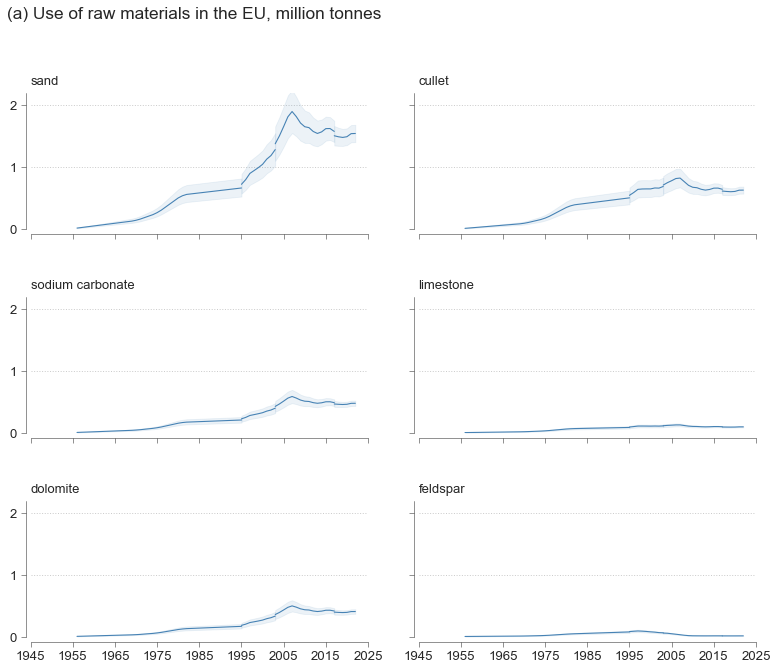

In [125]:
# Plot the absolute use of raw materials for IGU consumption in the EU:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [f"{mat}, consumption", '[kt], average'],
                linewidth=1.1, c='steelblue', linestyle='-')

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, consumption", '[kt], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{mat}, consumption", '[kt], min.')],
                        alpha=0.10, color='steelblue')

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_title(mat, loc='left', fontsize=13, y=1.02)
    style_ax(ax)

ax.set_ylim(0, 2200)
ax.set_xlim(1945, 2025)
plt.yticks(np.arange(0, 2201, 1000))
plt.xticks(np.arange(1945, 2026, 10))

# Divide by 1000 the y-axis, results in Mt:
ax.yaxis.set_major_formatter(y_1000)

# ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# Why I can't divide by 1000 and add a decimal?

fig.suptitle("(a) Use of raw materials in the EU, million tonnes",
             x=0.1, y=1, ha='left')
fig.subplots_adjust(wspace=0.15, hspace=0.5)

sns.despine(offset=5)
plt.show()

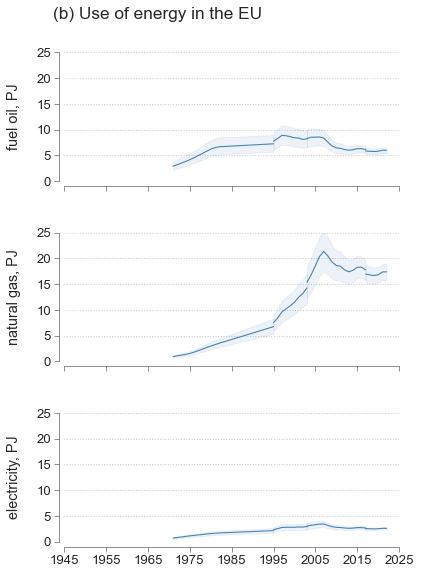

In [126]:
# Plot the absolute use of energy in the EU for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for a, b in EU_COUNTRIES:
        ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{energy}, consumption", '[PJ], average')],
                linewidth=1.1, c='steelblue', linestyle='-')

        ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year']).index,
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, consumption", '[PJ], max.')],
                        df_eu.interpolate().rolling(3, center=True).mean()
                        .loc[a:b].reset_index(level='Nbr of countries')
                        .sort_values(by=['year'])
                        [(f"{energy}, consumption", '[PJ], min.')],
                        alpha=0.10, color='steelblue')

        ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

    ax.set_ylabel(f"{energy}, PJ", labelpad=15)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 25)
plt.yticks(np.arange(0, 26, 5))

fig.suptitle("(b) Use of energy in the EU", x=0.1, y=0.95, ha='left')
fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)
plt.show()

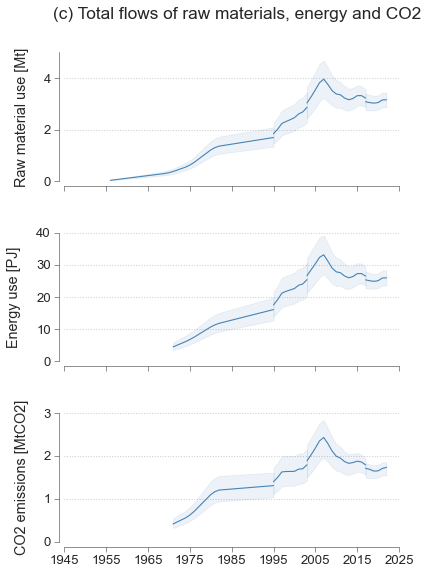

In [127]:
# Plot total energy & material use, total CO2 emissions for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

# Total use of raw materials:
ax = axes[0]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total raw materials, consumption', '[Mt], average')],
            linewidth=1.1, c='steelblue', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total raw materials, consumption", '[Mt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total raw materials, consumption", '[Mt], min.')],
                    alpha=0.10, color='steelblue')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Raw material use [Mt]", labelpad=15)
style_ax(ax)
ax.set_ylim(0, 5)
ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))

# Total use of energy:
ax = axes[1]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total energy, consumption', '[PJ], average')],
            linewidth=1.1, c='steelblue', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total energy, consumption", '[PJ], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total energy, consumption", '[PJ], min.')],
                    alpha=0.10, color='steelblue')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Energy use [PJ]", labelpad=15)
style_ax(ax)
ax.set_ylim(0, 40)

# Total emissions of CO2:
ax = axes[2]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('co2, production', '[kt], average')],
            linewidth=1.1, c='steelblue', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], min.')],
                    alpha=0.10, color='steelblue')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

# Divide by 1000 the y-axis, results in Mt
ax.yaxis.set_major_formatter(y_1000)

ax.set_ylabel("CO2 emissions [MtCO2]", labelpad=15)
style_ax(ax)
ax.set_ylim(0, 3000)

fig.suptitle("(c) Total flows of raw materials, energy and CO2",
             x=0.1, y=0.95, ha='left')

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [128]:
df_eu_rolled = df_eu.interpolate().rolling(3, center=True).mean()

# Use of raw materials, max. value:
Y_max = (df_eu_rolled[('Total raw materials, consumption', '[Mt], average')]
         .idxmax())
print("In year:")
print(Y_max)

MAT = df_eu_rolled['Total raw materials, consumption'].loc[Y_max]
print("----\nPeak value of raw material use:", "\n",
      MAT[0].round(2), MAT.index[0])
print("Min:", MAT[1].round(2), "; and max:", MAT[2].round(2),)

SAND = df_eu_rolled['sand, consumption'].loc[Y_max]
print("----\nTotal use of sand:", "\n", SAND[0].round(2), SAND.index[0])
print("Min:", SAND[1].round(2), "; and max:", SAND[2].round(2),)

SODA = df_eu_rolled['sodium carbonate, consumption'].loc[Y_max]
print("----\nAnd of sodium carbonate:", "\n", SODA[0].round(2), SODA.index[0])
print("Min:", SODA[1].round(2), "; and max:", SODA[2].round(2))

In year:
(27, 2007)
----
Peak value of raw material use: 
 3.95 [Mt], average
Min: 3.23 ; and max: 4.68
----
Total use of sand: 
 1898.49 [kt], average
Min: 1550.74 ; and max: 2246.24
----
And of sodium carbonate: 
 585.26 [kt], average
Min: 478.06 ; and max: 692.47


In [129]:
# Use of energy, max. value:
Y_max = (df_eu_rolled[('Total energy, consumption', '[PJ], average')]
         .idxmax())
print("In year:", Y_max)

ENERGY = df_eu_rolled['Total energy, consumption'].loc[Y_max]
print("----\nPeak value of energy use:", "\n",
      ENERGY[0].round(2), ENERGY.index[0])
print("Min:", ENERGY[1].round(2), "; and max:", ENERGY[2].round(2),)

GAS = df_eu_rolled['natural gas, consumption'].loc[Y_max]
print("----\nTotal use of natural gas:", "\n",
      GAS[0].round(2), GAS.index[0])
print("Min:", GAS[1].round(2), "; and max:", GAS[2].round(2),)

FUEL = df_eu_rolled['fuel oil, consumption'].loc[Y_max]
print("----\nAnd of fuel oil:", "\n", FUEL[0].round(2), FUEL.index[0])
print("Min:", FUEL[1].round(2), "; and max:", FUEL[2].round(2))

In year: (27, 2007)
----
Peak value of energy use: 
 33.07 [PJ], average
Min: 27.01 ; and max: 39.14
----
Total use of natural gas: 
 21.33 [PJ], average
Min: 17.42 ; and max: 25.24
----
And of fuel oil: 
 8.35 [PJ], average
Min: 6.81 ; and max: 9.88


In [130]:
# CO2 emissions, max. value:
Y_max = (df_eu_rolled[('co2, consumption', '[kt], average')]
         .idxmax())
print("In year:", Y_max)

CO2 = df_eu_rolled['co2, consumption'].loc[Y_max]
print("----\nPeak value of CO2 emissions:", "\n",
      CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

In year: (27, 2007)
----
Peak value of CO2 emissions: 
 2390.77 [kt], average
Min: 1952.65 ; and max: 2828.9


In [131]:
# Year 1971:
Y = (6, 1971)

MAT = df_eu_rolled['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:", "\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_eu_rolled['sand, consumption'].loc[Y]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_eu_rolled['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_eu_rolled['Total energy, consumption'].loc[Y]
print("Use of energy:", "\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_eu_rolled['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_eu_rolled['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_eu_rolled['co2, consumption'].loc[Y]
print("CO2 emissions:", "\n", CO2[0].round(2), CO2.index[0])
print("Min.:,", CO2[1].round(2), "; Max.:,", CO2[2].round(2))

Use of raw materials: 
 0.37 [Mt], average
----
Total use of sand: 157.19 [kt], average
And of sodium carbonate: 47.73 [kt], average
----
----
Use of energy: 
 4.45 [PJ], average
----
Total use of natural gas: 0.92 [PJ], average
And of fuel oil: 2.87 [PJ], average
----
----
CO2 emissions: 
 408.91 [kt], average
Min.:, 314.17 ; Max.:, 536.04


In [132]:
# Year 2018:
Y = (272020, 2018)

MAT = df_eu_rolled['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:", "\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_eu_rolled['sand, consumption'].loc[Y]

print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_eu_rolled['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_eu_rolled['Total energy, consumption'].loc[Y]
print("Use of energy:", "\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_eu_rolled['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_eu_rolled['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_eu_rolled['co2, consumption'].loc[Y]
print("CO2 emissions:", "\n", CO2[0].round(2), CO2.index[0])

Use of raw materials: 
 3.04 [Mt], average
----
Total use of sand: 1489.58 [kt], average
And of sodium carbonate: 458.97 [kt], average
----
----
Use of energy: 
 25.01 [PJ], average
----
Total use of natural gas: 16.76 [PJ], average
And of fuel oil: 5.77 [PJ], average
----
----
CO2 emissions: 
 1635.01 [kt], average


In [133]:
# Year 2022:
Y = (272020, 2022)

MAT = df_eu_rolled['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:", "\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_eu_rolled['sand, consumption'].loc[Y]

print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_eu_rolled['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_eu_rolled['Total energy, consumption'].loc[Y]
print("Use of energy:", "\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_eu_rolled['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_eu_rolled['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_eu_rolled['co2, consumption'].loc[Y]
print("CO2 emissions:", "\n", CO2[0].round(2), CO2.index[0])

Use of raw materials: 
 3.15 [Mt], average
----
Total use of sand: 1543.07 [kt], average
And of sodium carbonate: 475.45 [kt], average
----
----
Use of energy: 
 25.91 [PJ], average
----
Total use of natural gas: 17.37 [PJ], average
And of fuel oil: 5.98 [PJ], average
----
----
CO2 emissions: 
 1693.73 [kt], average


# The Belgian and French Production of IGU: Environmental Analysis

## Raw Material Flows

In [134]:
print("List of materials:", materials)
print("Levels are:", levels)

List of materials: ['sand', 'cullet', 'sodium carbonate', 'limestone', 'dolomite', 'feldspar']
Levels are: ['average', 'min.', 'max.']


In [135]:
# Absolute use of raw materials for IGU production:
for mat in materials:
    for level in levels:
        for country in countries:
            df_be_fr[(f"{mat}, production", f"[kt], {level}", country)] = (
                df_be_fr[('Production', f"[kt], {level}", country)]
                * (df_rawmat[(f"{mat}, kg/kg")]
                   .interpolate(method='pchip', limit_direction='forward'))
            )

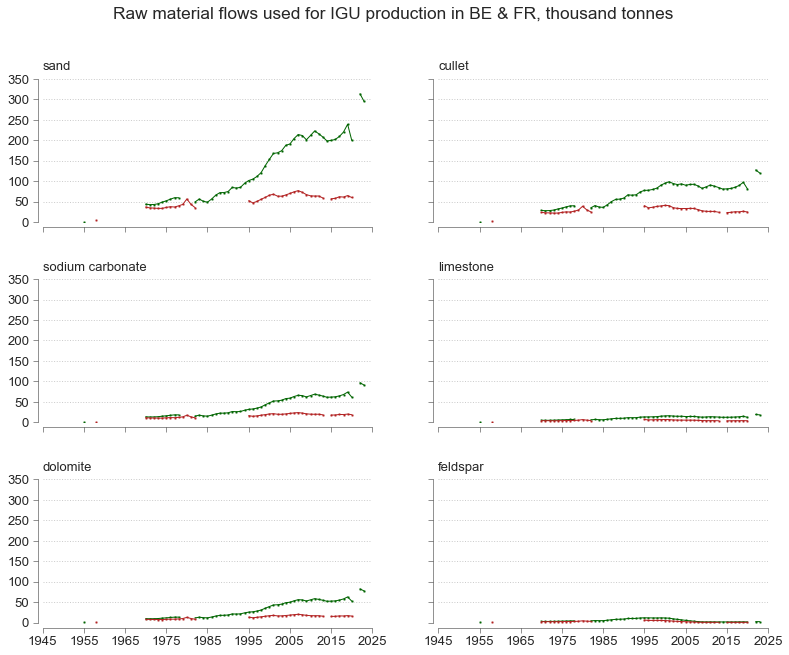

In [136]:
# Plot raw material flows for IGU production:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr[(f"{mat}, production", '[kt], average', country)],
                linewidth=1, c=color
                )

        sns.scatterplot(data=df_be_fr[(f"{mat}, production",
                                       '[kt], average', country)],
                        color=color, ax=ax, marker='.', s=30
                        )

    ax.set_title(f"{mat}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_ylabel(None)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))

fig.suptitle(
    "Raw material flows used for IGU production in BE & FR, thousand tonnes"
)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

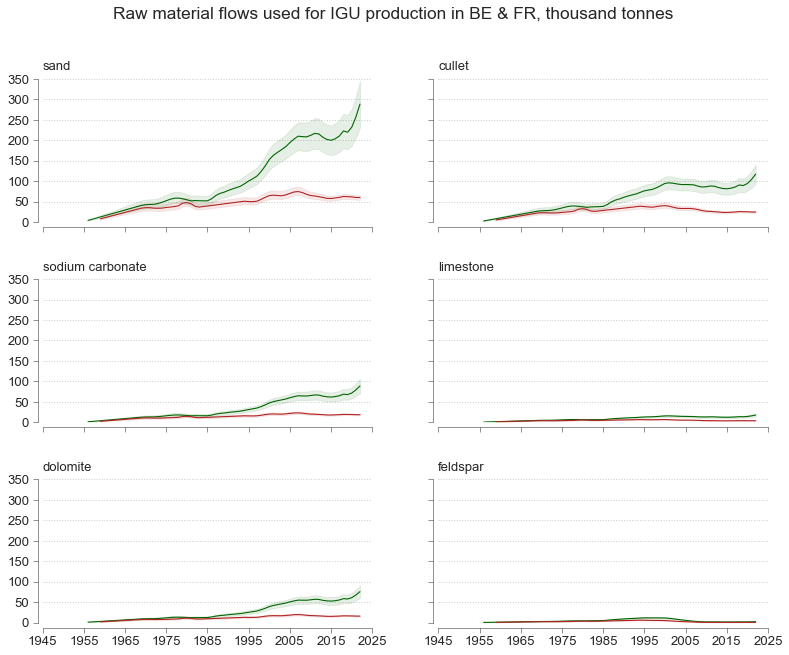

In [137]:
# Plot raw material flows for IGU production:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
                [(f"{mat}, production", '[kt], average', country)],
                linewidth=1.1, c=color
                )

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, production", '[kt], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, production", '[kt], min.', country)],
                        alpha=0.10, color=color)

    ax.set_title(f"{mat}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))

fig.suptitle(
    "Raw material flows used for IGU production in BE & FR, thousand tonnes"
)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [138]:
# Estimate total use of raw materials (sum per material):
for level in levels:
    for country in countries:
        df_be_fr[('Total raw materials, production',
                  f'[kt], {level}', country)] = 0

for mat in materials:
    for level in levels:
        for country in countries:
            df_be_fr[('Total raw materials, production',
                      f'[kt], {level}', country)] = (
                df_be_fr[(f"{mat}, production",
                          f'[kt], {level}', country)]
                + df_be_fr[('Total raw materials, production',
                            f'[kt], {level}', country)]
            )

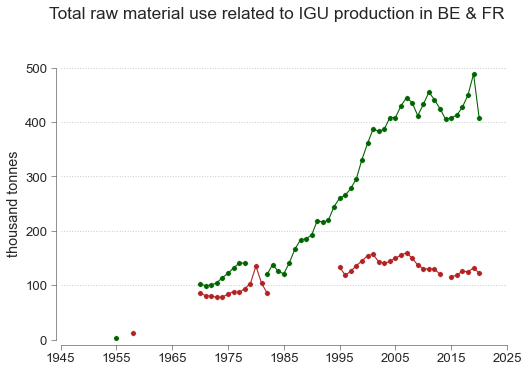

In [139]:
# Plot total material use for IGU production in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr[('Total raw materials, production',
                      '[kt], average', country)],
            linewidth=1.1, c=color, linestyle='-'
            )

    sns.scatterplot(data=df_be_fr[('Total raw materials, production',
                                   '[kt], average', country)],
                    color=color, s=30
                    )
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.set_ylabel("thousand tonnes")

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))

ax.set_ylim(0, 500)

style_ax(ax)

fig.suptitle("Total raw material use related to IGU production in BE & FR",
             y=1.05)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

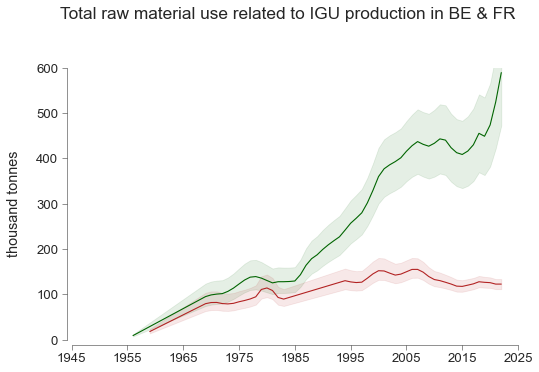

In [140]:
# Plot total material use for IGU production in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total raw materials, production', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, production',
                      '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, production',
                      '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 600)
ax.set_ylabel("thousand tonnes", labelpad=15)
style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total raw material use related to IGU production in BE & FR",
             y=1.05)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Energy Use

In [141]:
# Absolute use of energy for IGU production:
for energy in energies:
    for level in levels:
        for country in countries:
            df_be_fr[(f"{energy}, production", f"[PJ], {level}", country)] = (
                df_be_fr[('Production', f"[kt], {level}", country)]/1000
                * (df_be_fr_energy[(f"{energy}, GJ/t", country)]
                   .interpolate(method='pchip', limit_direction='forward'))
            )

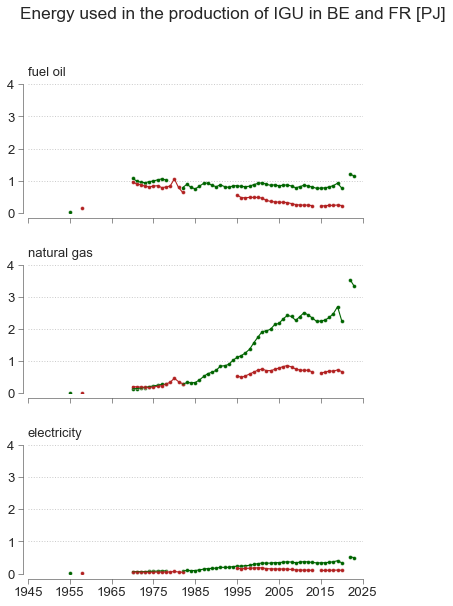

In [142]:
# Plot energy flows for IGU production:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr[(f"{energy}, production", '[PJ], average', country)],
                linewidth=1.1, c=color
                )

        sns.scatterplot(data=df_be_fr[(f"{energy}, production",
                                       '[PJ], average', country)],
                        color=color, ax=ax, s=15)

    ax.set_title(f"{energy}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.yaxis.label.set_visible(False)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 4)
plt.yticks(np.arange(0, 4.1, 1))

fig.suptitle("Energy used in the production of IGU in BE and FR [PJ]",
             y=1, x=0.6)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

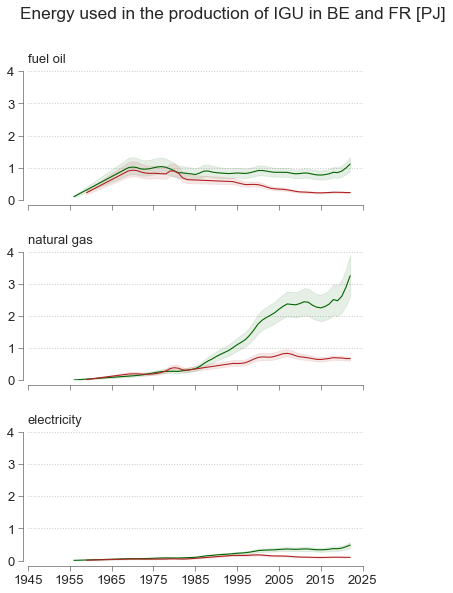

In [143]:
# Plot energy flows for IGU production:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
                [(f"{energy}, production", '[PJ], average', country)],
                linewidth=1.1, c=color
                )

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, production", '[PJ], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, production", '[PJ], min.', country)],
                        alpha=0.10, color=color)

    ax.set_title(f"{energy}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 4)
plt.yticks(np.arange(0, 4.1, 1))

fig.suptitle("Energy used in the production of IGU in BE and FR [PJ]", x=0.6)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [144]:
# Estimate total energy use (sum per energy type):
for level in levels:
    for country in countries:
        df_be_fr[('Total energy, production', f'[PJ], {level}', country)] = 0

for energy in energies:
    for level in levels:
        for country in countries:
            df_be_fr[('Total energy, production',
                      f'[PJ], {level}', country)] = (
                df_be_fr[(f"{energy}, production", f'[PJ], {level}', country)]
                + df_be_fr[('Total energy, production',
                            f'[PJ], {level}', country)]
            )

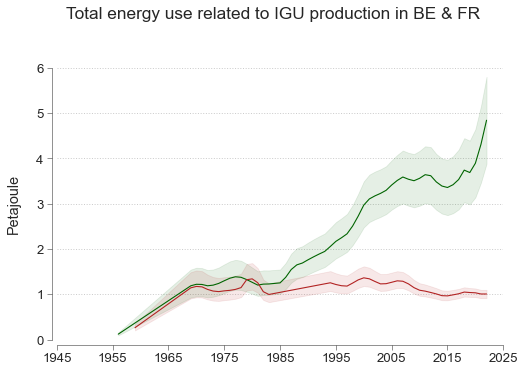

In [145]:
# Plot total energy use for IGU production in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total energy, production', '[PJ], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, production',
                      '[PJ], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, production',
                      '[PJ], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 6)

style_ax(ax)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
ax.set_ylabel("Petajoule", labelpad=15)

fig.suptitle("Total energy use related to IGU production in BE & FR", y=1.05)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Absolute CO2 Emissions

In [146]:
# Estimate the CO2 emission related to IGU production:
for level in levels:
    for country in countries:
        df_be_fr[('co2, production', f"[kt], {level}", country)] = (
            df_be_fr[('Production', f"[kt], {level}", country)]
            * fr_co2_intensity['CO2 interpolated [kg/t]'] / 1000
        )

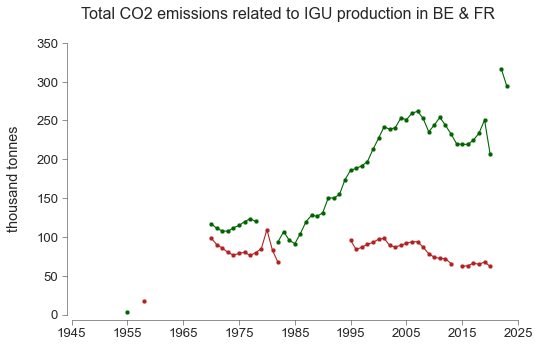

In [147]:
# Plot total CO2 emissions for IGU production in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr[('co2, production', '[kt], average', country)],
            linewidth=1.1, color=color, linestyle='-'
            )

    sns.scatterplot(data=df_be_fr[('co2, production',
                                   '[kt], average', country)],
                    color=color, ax=ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
style_ax(ax)
ax.set_ylabel("thousand tonnes", labelpad=15)

fig.suptitle("Total CO2 emissions related to IGU production in BE & FR",
             fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

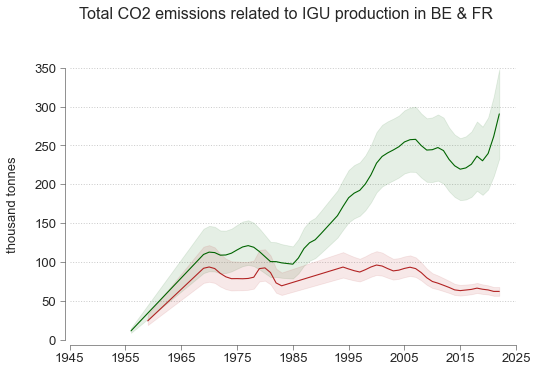

In [148]:
# Plot total CO2 emissions for IGU production in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('co2, production', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, production', '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, production', '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 350)

style_ax(ax)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
ax.set_ylabel("thousand tonnes", labelpad=15, fontsize=13)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total CO2 emissions related to IGU production in BE & FR",
             y=1.05, fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

# The Belgian and French Consumption of IGU: Environmental Analysis

## Raw Material Flows

In [149]:
# Absolute use of raw materials for IGU consumption:
for mat in materials:
    for level in levels:
        for country in countries:
            df_be_fr[(f"{mat}, consumption", f"[kt], {level}", country)] = (
                df_be_fr[('Consumption', f"[kt], {level}", country)]
                * (df_rawmat[(f"{mat}, kg/kg")]
                   .interpolate(method='pchip', limit_direction='forward'))
            )

C:\Users\souvi\AppData\Local\Temp/ipykernel_22856/175001200.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df_be_fr[(f"{mat}, consumption", f"[kt], {level}", country)] = (


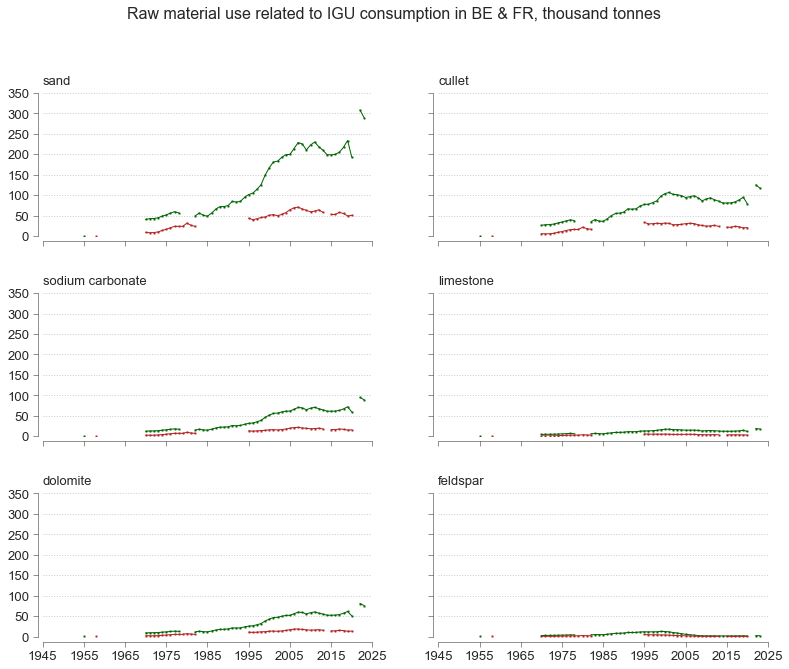

In [150]:
# Plot raw material flows for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr[(f"{mat}, consumption", '[kt], average', country)],
                linewidth=1, c=color
                )

        sns.scatterplot(data=df_be_fr[(f"{mat}, consumption",
                                       '[kt], average', country)],
                        color=color, ax=ax, marker='.', s=30
                        )

    ax.set_title(f"{mat}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.yaxis.label.set_visible(False)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))

fig.suptitle(
    "Raw material use related to IGU consumption in BE & FR, thousand tonnes",
    y=1, fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

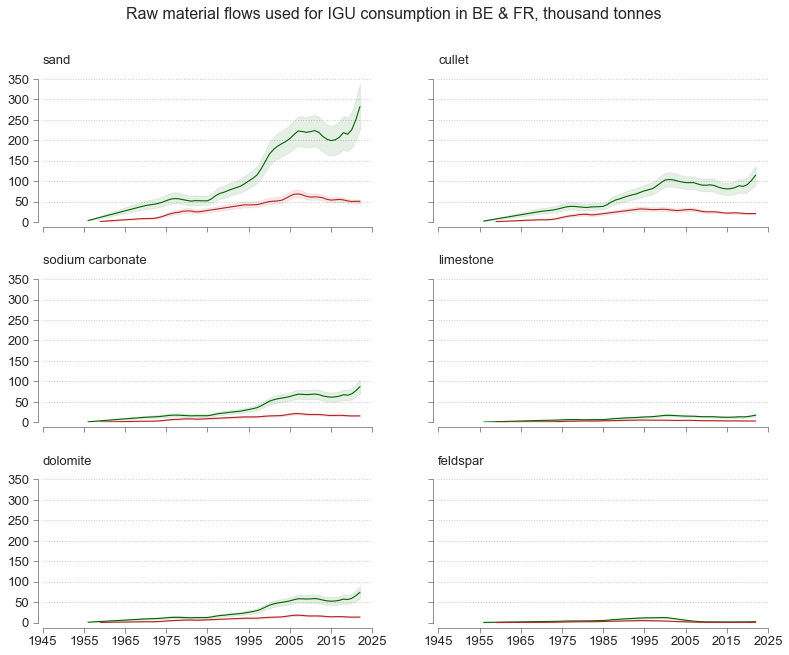

In [151]:
# Plot raw material flows for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(13, 10))

for i, (ax, mat) in enumerate(zip(axes.flatten(), materials)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
                [(f"{mat}, consumption", '[kt], average', country)],
                linewidth=1.1, c=color
                )

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, consumption", '[kt], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, consumption", '[kt], min.', country)],
                        alpha=0.10, color=color)
    ax.set_title(f"{mat}", loc='left', pad=15, fontsize=13)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))

fig.suptitle(
    "Raw material flows used for IGU consumption in BE & FR, thousand tonnes",
    fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [152]:
# Estimate total use of raw materials (sum per material):
for level in levels:
    for country in countries:
        df_be_fr[('Total raw materials, consumption',
                  f'[kt], {level}', country)] = 0

for mat in materials:
    for level in levels:
        for country in countries:
            df_be_fr[('Total raw materials, consumption',
                      f'[kt], {level}', country)] = (
                df_be_fr[(f"{mat}, consumption",
                          f'[kt], {level}', country)]
                + df_be_fr[('Total raw materials, consumption',
                            f'[kt], {level}', country)]
            )

C:\Users\souvi\AppData\Local\Temp/ipykernel_22856/3616002236.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df_be_fr[('Total raw materials, consumption',


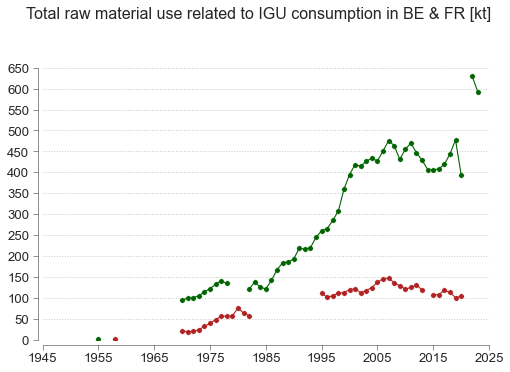

In [153]:
# Plot total material use for IGU consumption in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr[('Total raw materials, consumption',
                      '[kt], average', country)],
            linewidth=1.1, c=color, linestyle='-'
            )

    sns.scatterplot(data=df_be_fr[('Total raw materials, consumption',
                                   '[kt], average', country)],
                    color=color, s=30
                    )
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.yaxis.label.set_visible(False)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 650)
plt.yticks(np.arange(0, 651, 50))
style_ax(ax)

fig.suptitle("Total raw material use related to IGU consumption in BE & FR [kt]", 
             y=1.05, fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

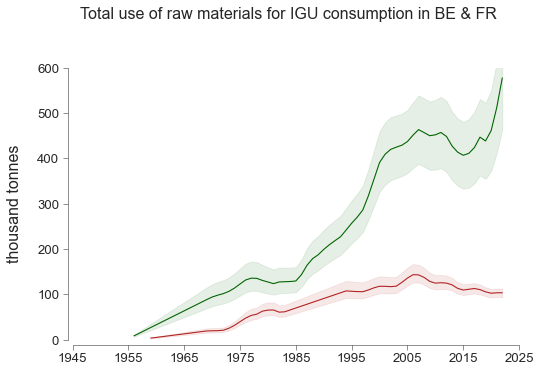

In [154]:
# Plot total material use for IGU consumption in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total raw materials, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, consumption',
                      '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, consumption',
                      '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 600)

# Add ylabel
ax.set_ylabel("thousand tonnes", fontsize=16, labelpad=15)

style_ax(ax)

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("Total use of raw materials for IGU consumption in BE & FR", 
             fontsize=16, y=1.05)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Energy Use

In [155]:
# Absolute use of energy for IGU consumption:
for energy in energies:
    for level in levels:
        for country in countries:
            df_be_fr[(f"{energy}, consumption", f"[PJ], {level}", country)] = (
                df_be_fr[('Consumption', f"[kt], {level}", country)]/1000
                * (df_be_fr_energy[(f"{energy}, GJ/t", country)]
                   .interpolate(method='pchip', limit_direction='forward'))
            )

C:\Users\souvi\AppData\Local\Temp/ipykernel_22856/23203851.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df_be_fr[(f"{energy}, consumption", f"[PJ], {level}", country)] = (


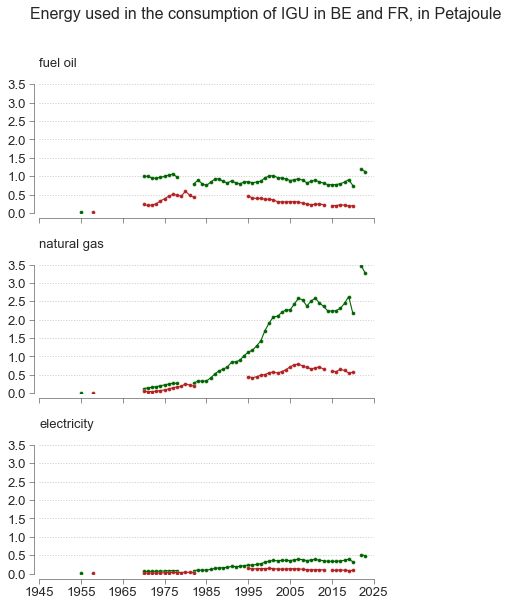

In [156]:
# Plot energy flows for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(
            df_be_fr[(f"{energy}, consumption", '[PJ], average', country)],
            linewidth=1.1, c=color
        )

        sns.scatterplot(data=df_be_fr[(f"{energy}, consumption",
                                       '[PJ], average', country)],
                        color=color, ax=ax, s=15)
    ax.set_title(f"{energy}", loc='left', pad=15, fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    ax.yaxis.label.set_visible(False)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 3.5)
plt.yticks(np.arange(0, 3.6, 0.5))

fig.suptitle(
    "Energy used in the consumption of IGU in BE and FR, in Petajoule",
    x=0.65, y=1, fontsize=16)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

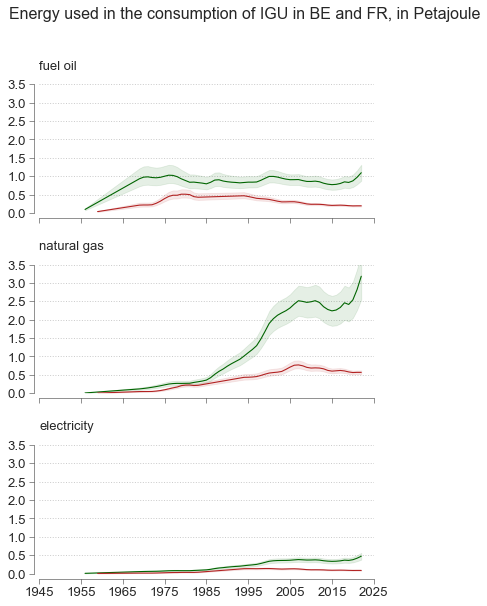

In [157]:
# Plot energy flows for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
                [(f"{energy}, consumption", '[PJ], average', country)],
                linewidth=1.1, c=color
                )

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, consumption", '[PJ], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, consumption", '[PJ], min.', country)],
                        alpha=0.10, color=color)

    ax.set_title(f"{energy}", loc='left', pad=15, fontsize=13)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 3.5)
plt.yticks(np.arange(0, 3.6, 0.5))

fig.suptitle(
    "Energy used in the consumption of IGU in BE and FR, in Petajoule",
    y=1, fontsize=16, x=0.6)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

In [158]:
# Estimate total energy use (sum per energy type):
for level in levels:
    for country in countries:
        df_be_fr[('Total energy, consumption', f'[PJ], {level}', country)] = 0

for energy in energies:
    for level in levels:
        for country in countries:
            df_be_fr[('Total energy, consumption',
                      f'[PJ], {level}', country)] = (
                df_be_fr[(f"{energy}, consumption", f'[PJ], {level}', country)]
                + df_be_fr[('Total energy, consumption',
                            f'[PJ], {level}', country)]
            )

C:\Users\souvi\AppData\Local\Temp/ipykernel_22856/3782638174.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df_be_fr[('Total energy, consumption', f'[PJ], {level}', country)] = 0


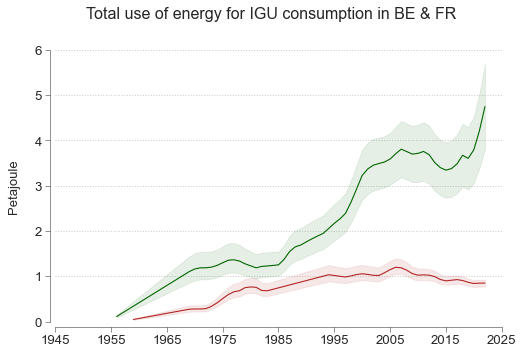

In [159]:
# Plot total energy use for IGU consumption in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total energy, consumption', '[PJ], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 6)
style_ax(ax)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
ax.set_ylabel("Petajoule", labelpad=15, fontsize=13)

fig.suptitle("Total use of energy for IGU consumption in BE & FR", 
             fontsize=16, y=1)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Absolute CO2 Emissions

In [160]:
# Estimate the CO2 emission related to IGU consumption:
for level in levels:
    for country in countries:
        df_be_fr[('co2, consumption', f"[kt], {level}", country)] = (
            df_be_fr[('Consumption', f"[kt], {level}", country)]
            * fr_co2_intensity['CO2 interpolated [kg/t]'] / 1000
        )

C:\Users\souvi\AppData\Local\Temp/ipykernel_22856/2835728035.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  df_be_fr[('co2, consumption', f"[kt], {level}", country)] = (


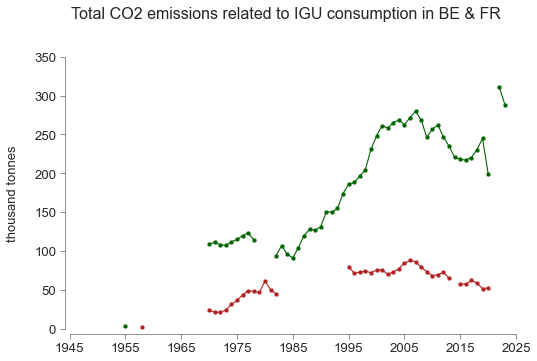

In [161]:
# Plot total CO2 emissions for IGU consumption in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr[('co2, consumption', '[kt], average', country)],
            linewidth=1.1, color=color, linestyle='-'
            )

    sns.scatterplot(data=df_be_fr[('co2, consumption',
                                   '[kt], average', country)],
                    color=color, ax=ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
style_ax(ax)
ax.set_ylabel("thousand tonnes", fontsize=13, labelpad=15)

fig.suptitle("Total CO2 emissions related to IGU consumption in BE & FR", 
             fontsize=16, y=1.02)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

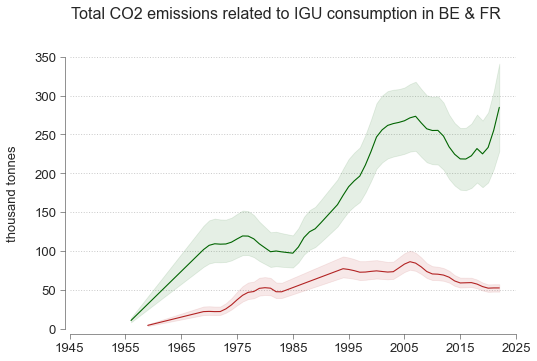

In [162]:
# Plot total CO2 emissions for IGU consumption in Belgium and France:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('co2, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)

style_ax(ax)
ax.set_ylabel("thousand tonnes", fontsize=13, labelpad=15)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

fig.suptitle("Total CO2 emissions related to IGU consumption in BE & FR", 
             fontsize=16, y=1.02)
fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)
plt.show()

## Summary

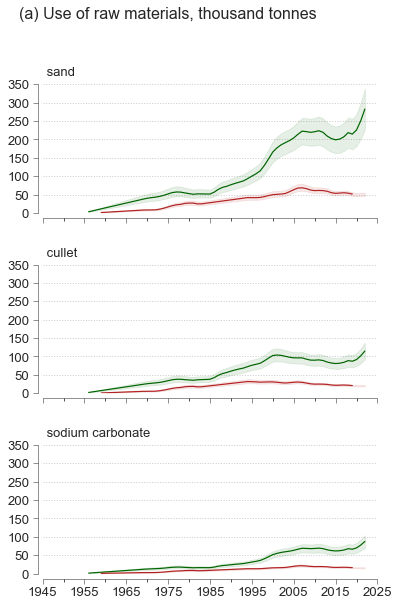

In [163]:
# Raw materials, per type:
mat_reduced = ['sand', 'cullet', 'sodium carbonate']

fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, mat) in enumerate(zip(axes.flatten(), mat_reduced)):
    for country in countries:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        (df_be_fr[(f"{mat}, consumption", '[kt], average', country)]
         .interpolate(method="linear", limit_area='inside')
         .rolling(3, center=True).mean()
         .plot(ax=ax, c=color))

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, consumption", '[kt], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{mat}, consumption", '[kt], min.', country)],
                        alpha=0.10, color=color)

    ax.set_title(f" {mat}", loc='left', fontsize=13, y=1.02)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 350)
plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 351, 50))

fig.suptitle("(a) Use of raw materials, thousand tonnes",
             x=0.07, y=1, ha='left', fontsize=16)
fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)
plt.show()

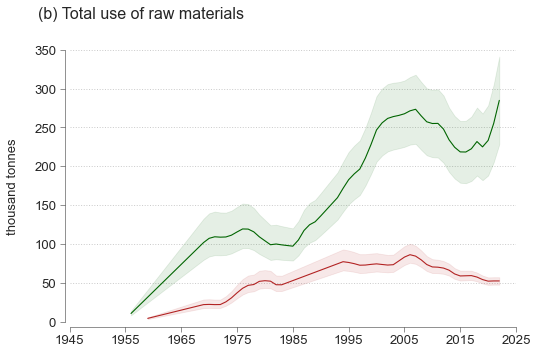

In [164]:
# Raw materials, total:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('co2, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], min.', country)],
                    alpha=0.10, color=color)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))

ax.set_ylabel("thousand tonnes", fontsize=13, labelpad=15)

fig.suptitle("(b) Total use of raw materials", x=0.07, y=1, ha='left', 
             fontsize=16)

sns.despine(offset=5)
plt.show()

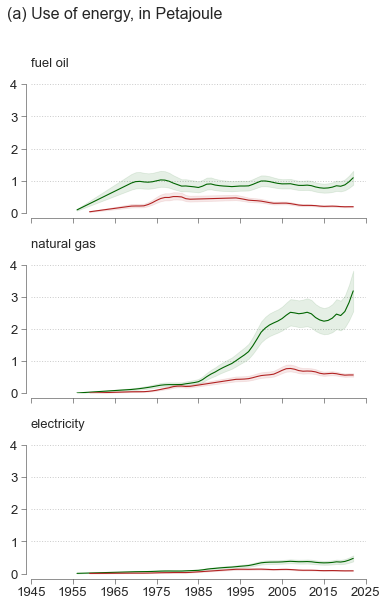

In [165]:
# Energy use, per type:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, energy) in enumerate(zip(axes.flatten(), energies)):
    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
            ax.set_title(f"{energy}", loc='left', pad=15, fontsize=13, y=1.02)
        else:
            color = 'darkgreen'

        ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
                [(f"{energy}, consumption", '[PJ], average', country)],
                linewidth=1.1, c=color
                )

        ax.fill_between(df_be_fr.index,
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, consumption", '[PJ], max.', country)],
                        df_be_fr.interpolate().rolling(3, center=True).mean()
                        [(f"{energy}, consumption", '[PJ], min.', country)],
                        alpha=0.10, color=color)

        ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
        style_ax(ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 4)
plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("(a) Use of energy, in Petajoule", 
             x=0.07, y=1, ha='left', fontsize=16)
fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)
plt.show()

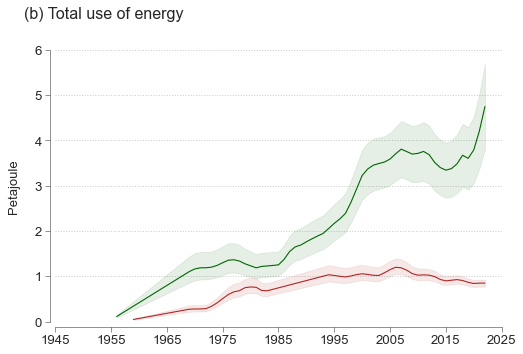

In [166]:
# Energy use, total:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total energy, consumption', '[PJ], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], min.', country)],
                    alpha=0.10, color=color)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))

ax.set_ylim(0, 6)
plt.yticks(np.arange(0, 6.1, 1))

ax.set_ylabel("Petajoule", fontsize=13, labelpad=15)

fig.suptitle("(b) Total use of energy", 
             x=0.07, y=1, ha='left', fontsize=16)

sns.despine(offset=5)
plt.show()

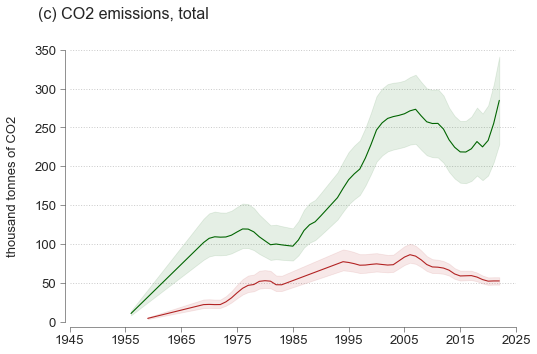

In [167]:
# CO2 emissions, total:
fig, ax = plt.subplots(figsize=(8, 5))

for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('co2, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], min.', country)],
                    alpha=0.10, color=color)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 350)
plt.yticks(np.arange(0, 351, 50))
ax.set_ylabel("thousand tonnes of CO2", labelpad=15, fontsize=13)

fig.suptitle("(c) CO2 emissions, total", 
             x=0.07, y=1, ha='left', fontsize=16)

sns.despine(offset=5)
plt.show()

In [168]:
# New DataFrame, one for each country:
df_fr = (df_be_fr.interpolate().rolling(3, center=True).mean()
         .iloc[:, df_be_fr.columns.get_level_values(2) == 'France']
         .droplevel('Country', axis=1))

df_be = (df_be_fr.interpolate().rolling(3, center=True).mean()
         .iloc[:, df_be_fr.columns.get_level_values(2) == 'Belgium']
         .rolling(3, center=True).mean().droplevel('Country', axis=1))

In [169]:
# Use of raw materials, max. value, FRANCE:
Y_max = (df_fr[('Total raw materials, consumption', '[kt], average')].idxmax())
print("France, in year:", Y_max)

MAT = df_fr['Total raw materials, consumption'].loc[Y_max]
print("----\nPeak value of raw material use:\n",
      MAT[0].round(2), MAT.index[0])
print("Min:", MAT[1].round(2), "; and max:", MAT[2].round(2),)

SAND = df_fr['sand, consumption'].loc[Y_max]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
print("Min:", SAND[1].round(2), "; and max:", SAND[2].round(2),)

SODA = df_fr['sodium carbonate, consumption'].loc[Y_max]
print("----\nAnd of sodium carbonate:", SODA[0].round(2), SODA.index[0])
print("Min:", SODA[1].round(2), "; and max:", SODA[2].round(2),)

France, in year: 2022
----
Peak value of raw material use:
 577.51 [kt], average
Min: 463.15 ; and max: 691.87
----
Total use of sand: 282.58 [kt], average
Min: 226.62 ; and max: 338.53
----
And of sodium carbonate: 87.07 [kt], average
Min: 69.83 ; and max: 104.31


In [170]:
# Use of raw materials, max. value, BELGIUM:
Y_max = (df_be[('Total raw materials, consumption', '[kt], average')].idxmax())
print("Belgium, in year:", Y_max)

MAT = df_be['Total raw materials, consumption'].loc[Y_max]
print("----\nPeak value of raw material use:\n",
      MAT[0].round(2), MAT.index[0])
print("Min:", MAT[1].round(2), "; and max:", MAT[2].round(2),)

SAND = df_be['sand, consumption'].loc[Y_max]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
print("Min:", SAND[1].round(2), "; and max:", SAND[2].round(2),)

SODA = df_be['sodium carbonate, consumption'].loc[Y_max]
print("----\nAnd of sodium carbonate:", SODA[0].round(2), SODA.index[0])
print("Min:", SODA[1].round(2), "; and max:", SODA[2].round(2),)

Belgium, in year: 2007
----
Peak value of raw material use:
 140.86 [kt], average
Min: 124.18 ; and max: 163.2
----
Total use of sand: 67.55 [kt], average
Min: 59.55 ; and max: 78.26
----
And of sodium carbonate: 20.82 [kt], average
Min: 18.36 ; and max: 24.13


In [171]:
# Use of energy, max. value, FRANCE:
Y_max = (df_fr[('Total energy, consumption', '[PJ], average')].idxmax())
print("France, in year:", Y_max)

ENERGY = df_fr['Total energy, consumption'].loc[Y_max]
print("----\nPeak value of energy use:\n",
      ENERGY[0].round(2), ENERGY.index[0])
print("Min:", ENERGY[1].round(2), "; and max:", ENERGY[2].round(2),)

GAS = df_fr['natural gas, consumption'].loc[Y_max]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
print("Min:", GAS[1].round(2), "; and max:", GAS[2].round(2))

FUEL = df_fr['fuel oil, consumption'].loc[Y_max]
print("----\nAnd of fuel oil:", FUEL[0].round(2), FUEL.index[0])
print("Min:", FUEL[1].round(2), "; and max:", FUEL[2].round(2),)

print("----\n----")

# CO2 emissions, max. value, FRANCE:
CO2 = df_fr['co2, consumption'].loc[Y_max]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

France, in year: 2022
----
Peak value of energy use:
 4.74 [PJ], average
Min: 3.8 ; and max: 5.68
----
Total use of natural gas: 3.18 [PJ], average
Min: 2.55 ; and max: 3.81
----
And of fuel oil: 1.09 [PJ], average
Min: 0.88 ; and max: 1.31
----
----
Peak value of CO2 emissions:
 284.73 [kt], average
Min: 228.36 ; and max: 341.11


In [172]:
# Use of energy, max. value, BELGIUM:
Y_max = (df_be[('Total energy, consumption', '[PJ], average')].idxmax())
print("Belgium, in year:", Y_max)

ENERGY = df_be['Total energy, consumption'].loc[Y_max]
print("----\nPeak value of energy use:\n",
      ENERGY[0].round(2), ENERGY.index[0])
print("Min:", ENERGY[1].round(2), "; and max:", ENERGY[2].round(2),)

GAS = df_be['natural gas, consumption'].loc[Y_max]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
print("Min:", GAS[1].round(2), "; and max:", GAS[2].round(2),)

FUEL = df_be['fuel oil, consumption'].loc[Y_max]
print("----\nAnd of fuel oil:", FUEL[0].round(2), FUEL.index[0])
print("Min:", FUEL[1].round(2), "; and max:", FUEL[2].round(2),)

print("----\n----")

# CO2 emissions, max. value, BELGIUM:
CO2 = df_be['co2, consumption'].loc[Y_max]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

Belgium, in year: 2006
----
Peak value of energy use:
 1.18 [PJ], average
Min: 1.03 ; and max: 1.37
----
Total use of natural gas: 0.75 [PJ], average
Min: 0.66 ; and max: 0.87
----
And of fuel oil: 0.3 [PJ], average
Min: 0.27 ; and max: 0.35
----
----
Peak value of CO2 emissions:
 84.39 [kt], average
Min: 74.22 ; and max: 98.2


In [173]:
# France, year 1960:
Y = 1960
print('France,', Y, '\n')

MAT = df_fr['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_fr['sand, consumption'].loc[Y]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_fr['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_fr['Total energy, consumption'].loc[Y]
print("Use of energy:\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_fr['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_fr['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_fr['co2, consumption'].loc[Y]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

France, 1960 

Use of raw materials:
 32.62 [kt], average
----
Total use of sand: 13.99 [kt], average
And of sodium carbonate: 4.25 [kt], average
----
----
Use of energy:
 0.41 [PJ], average
----
Total use of natural gas: 0.04 [PJ], average
And of fuel oil: 0.35 [PJ], average
----
----
Peak value of CO2 emissions:
 38.43 [kt], average
Min: 29.95 ; and max: 50.18


In [174]:
# France, year 2019:
Y = 2019
print('France,', Y, '\n')

MAT = df_fr['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_fr['sand, consumption'].loc[Y]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_fr['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_fr['Total energy, consumption'].loc[Y]
print("Use of energy:\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_fr['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_fr['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_fr['co2, consumption'].loc[Y]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

France, 2019 

Use of raw materials:
 438.33 [kt], average
----
Total use of sand: 214.48 [kt], average
And of sodium carbonate: 66.08 [kt], average
----
----
Use of energy:
 3.6 [PJ], average
----
Total use of natural gas: 2.41 [PJ], average
And of fuel oil: 0.83 [PJ], average
----
----
Peak value of CO2 emissions:
 224.88 [kt], average
Min: 181.95 ; and max: 267.8


In [175]:
# Belgium, year 1960:
Y = 1960
print('Belgium,', Y, '\n')

MAT = df_be['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_be['sand, consumption'].loc[Y]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_be['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_be['Total energy, consumption'].loc[Y]
print("Use of energy:\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_be['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_be['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_be['co2, consumption'].loc[Y]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

Belgium, 1960 

Use of raw materials:
 4.63 [kt], average
----
Total use of sand: 1.99 [kt], average
And of sodium carbonate: 0.61 [kt], average
----
----
Use of energy:
 0.07 [PJ], average
----
Total use of natural gas: 0.01 [PJ], average
And of fuel oil: 0.06 [PJ], average
----
----
Peak value of CO2 emissions:
 5.8 [kt], average
Min: 4.55 ; and max: 7.67


In [176]:
# Belgium, year 2019:
Y = 2019
print('Belgium,', Y, '\n')

MAT = df_be['Total raw materials, consumption'].loc[Y]
print("Use of raw materials:\n",
      MAT[0].round(2), MAT.index[0])
SAND = df_be['sand, consumption'].loc[Y]
print("----\nTotal use of sand:", SAND[0].round(2), SAND.index[0])
SODA = df_be['sodium carbonate, consumption'].loc[Y]
print("And of sodium carbonate:", SODA[0].round(2), SODA.index[0])

print("----\n----")

ENERGY = df_be['Total energy, consumption'].loc[Y]
print("Use of energy:\n",
      ENERGY[0].round(2), ENERGY.index[0])
GAS = df_be['natural gas, consumption'].loc[Y]
print("----\nTotal use of natural gas:", GAS[0].round(2), GAS.index[0])
FUEL = df_be['fuel oil, consumption'].loc[Y]
print("And of fuel oil:", FUEL[0].round(2), FUEL.index[0])

print("----\n----")

CO2 = df_be['co2, consumption'].loc[Y]
print("Peak value of CO2 emissions:\n", CO2[0].round(2), CO2.index[0])
print("Min:", CO2[1].round(2), "; and max:", CO2[2].round(2),)

Belgium, 2019 

Use of raw materials:
 105.88 [kt], average
----
Total use of sand: 51.8 [kt], average
And of sodium carbonate: 15.96 [kt], average
----
----
Use of energy:
 0.87 [PJ], average
----
Total use of natural gas: 0.58 [PJ], average
And of fuel oil: 0.2 [PJ], average
----
----
Peak value of CO2 emissions:
 54.4 [kt], average
Min: 49.32 ; and max: 59.65


# Figures for publication

## Glass Thickness in Insulating Glass Units

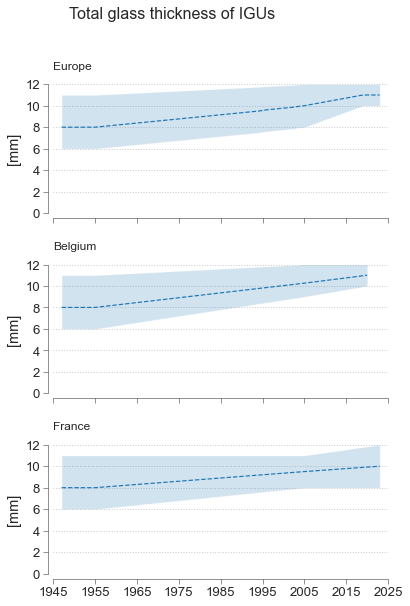

In [177]:
regions = ['Europe', 'Belgium', 'France']

fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(6, 9))

for i, (ax, region) in enumerate(zip(axes.flatten(), regions)):
    if region == 'Europe':
        sns.lineplot(data=df_eu_thick.reset_index('Nbr of countries').drop(
            labels='Nbr of countries', axis=1)['average thickness, mm'],
            linestyle='--', ax=ax)

        ax.fill_between(df_toplot.index, df_toplot['max. thickness, mm'],
                        df_toplot['min. thickness, mm'],
                        alpha=0.20)
    else:
        sns.lineplot(data=df_be_fr_thick[('average thickness, mm', region)],
                     linestyle='--', ax=ax)

        ax.fill_between(df_be_fr_thick.index,
                        df_be_fr_thick[('max. thickness, mm', region)],
                        df_be_fr_thick[('min. thickness, mm', region)],
                        alpha=0.20)

    ax.set_title(region, loc='left', pad=15)
    ax.set_ylabel("[mm]")
    ax.xaxis.label.set_visible(False)

    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
    style_ax(ax)

ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))
ax.set_ylim(0, 12)
plt.yticks(np.arange(0, 13, 2))

fig.suptitle("Total glass thickness of IGUs", fontsize=16, y=1, x=0.4)
sns.despine(offset=5)
fig.subplots_adjust(hspace=0.4)

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'Fig1_EU-BE-FR_IGU-Thickness.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'Fig1_EU-BE-FR_IGU-Thickness.pdf'),
                bbox_inches='tight')

## MEFA, Europe

Production and consumption of IGU in the EU 




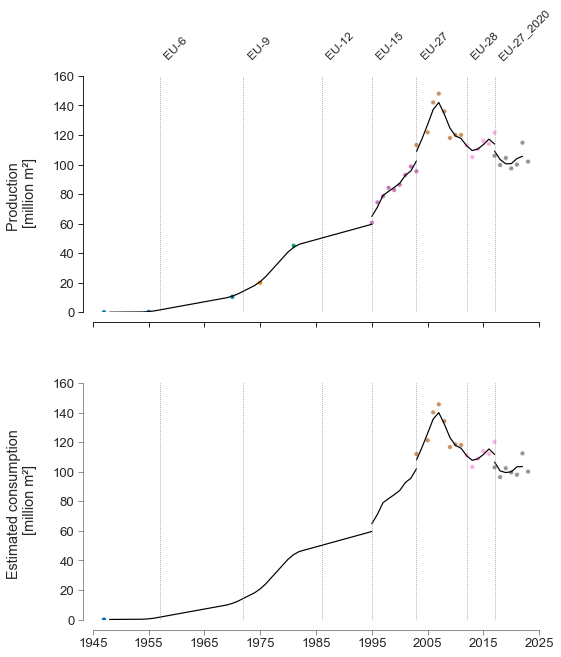

In [198]:
# Plot two figures:
fig, axes = plt.subplots(nrows=2, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(8, 10))

for row, data in enumerate(['Production', 'Estimated consumption']):
    for i, j in EU_COUNTRIES:
        ax = axes[row]
        # Plot the trend curve for IGU production:
        ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[i:j]
                .reset_index(level='Nbr of countries')
                .sort_values(by=['year'])
                [(f"{data}", "[10^6 m²]")],
                c='black', linestyle='-')

        if row == 0:
            # Plot data gathered from literature review:
            sns.scatterplot(data=df_eu["Production"].reset_index(),
                            x='year', y="[10^6 m²]",
                            hue='Nbr of countries',
                            palette='colorblind',
                            marker='.', s=100,
                            ax=ax)

        else:
            # Plot data gathered from literature review:
            sns.scatterplot(data=df_eu["Consumption"].reset_index(),
                            x='year', y="[10^6 m²]",
                            hue='Nbr of countries',
                            palette='colorblind',
                            marker='.', s=100,
                            ax=ax)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)
        if row == 0:
            ax.text(x+0.5, 170, f"{y}", fontsize=12,
                    verticalalignment='bottom', rotation=45)

    ax.get_legend().remove()
    ax.set_ylabel(f"{data} \n [million m²]", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)

style_ax(ax)
ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)

plt.xticks(np.arange(1945, 2026, 10))

fig.subplots_adjust(hspace=0.30)
sns.despine(offset=10)

print("Production and consumption of IGU in the EU \n\n")

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'Fig2_EU_IGUFlows.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'Fig2_EU_IGUFlows.pdf'),
                bbox_inches='tight')

plt.show()

Total flows of raw materials, energy and CO2 in the EU 




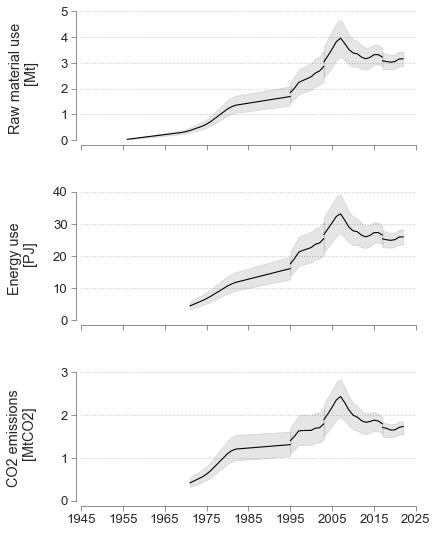

In [199]:
# Plot total energy & material use, total CO2 emissions for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

# Total use of raw materials:
ax = axes[0]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total raw materials, consumption', '[Mt], average')],
            linewidth=1.1, c='black', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total raw materials, consumption", '[Mt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total raw materials, consumption", '[Mt], min.')],
                    alpha=0.10, color='black')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Raw material use \n [Mt]", labelpad=21)
style_ax(ax)
ax.set_ylim(0, 5)
ax.set_yticks(np.arange(0, 6, 1))
ax.set_xlim(1945, 2025)
ax.set_xticks(np.arange(1945, 2026, 10))

# Total use of energy:
ax = axes[1]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('Total energy, consumption', '[PJ], average')],
            linewidth=1.1, c='black', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total energy, consumption", '[PJ], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [("Total energy, consumption", '[PJ], min.')],
                    alpha=0.10, color='black')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Energy use \n [PJ]", labelpad=15)
style_ax(ax)
ax.set_ylim(0, 40)

# Total emissions of CO2:
ax = axes[2]
for a, b in EU_COUNTRIES:
    ax.plot(df_eu.interpolate().rolling(3, center=True).mean().loc[a:b]
            .reset_index(level='Nbr of countries')
            .sort_values(by=['year'])
            [('co2, production', '[kt], average')],
            linewidth=1.1, c='black', linestyle='-')

    ax.fill_between(df_eu.loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year']).index,
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], max.')],
                    df_eu.interpolate().rolling(3, center=True).mean()
                    .loc[a:b].reset_index(level='Nbr of countries')
                    .sort_values(by=['year'])
                    [('co2, consumption', '[kt], min.')],
                    alpha=0.10, color='black')

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

# Divide by 1000 the y-axis, results in Mt
ax.yaxis.set_major_formatter(y_1000)

ax.set_ylabel("CO2 emissions \n [MtCO2]", labelpad=23)
style_ax(ax)
ax.set_ylim(0, 3000)

fig.subplots_adjust(hspace=0.4)
sns.despine(offset=5)

print("Total flows of raw materials, energy and CO2 in the EU \n\n")

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'Fig3_EU_TotalFlows.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'Fig3_EU_TotalFlows.pdf'),
                bbox_inches='tight')

plt.show()

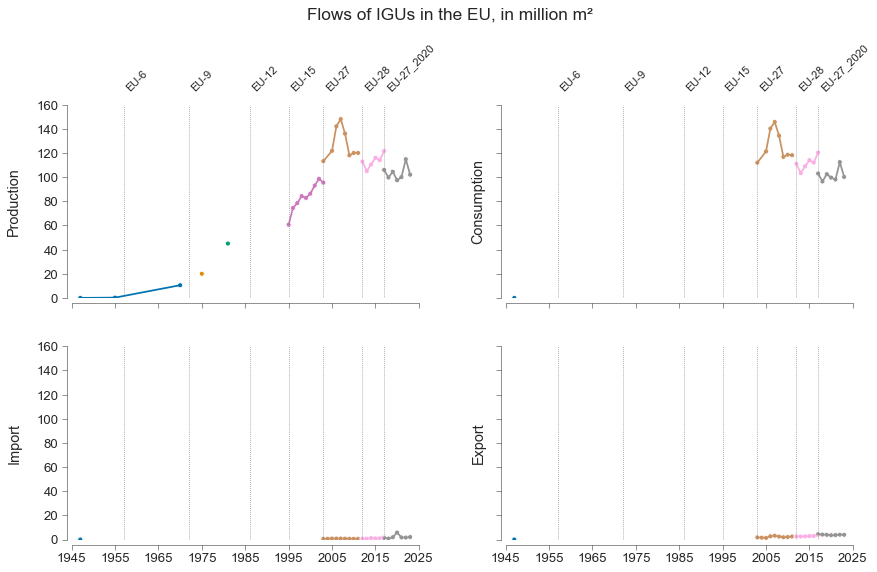

In [180]:
# Plot a synthesis of the results concerning European flows of IGU:
data1 = ['Production', 'Consumption']
data2 = ['Import', 'Export']

fig, axes = plt.subplots(nrows=2, ncols=2,
                         sharex=True, sharey=True,
                         figsize=(14, 8))

# Plot production and consumption:
for col, data in enumerate(data1):
    ax = axes[0][col]
    sns.lineplot(data=df_eu[f"{data}"].reset_index(),
                 x='year', y="[10^6 m²]",
                 hue='Nbr of countries',
                 palette='colorblind', linewidth=1.75,
                 ax=ax)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)
        ax.text(x+0.25, 170, f"{y}", fontsize=11,
                verticalalignment='bottom', rotation=45)

    # Plot data gathered from literature review:
    sns.scatterplot(data=df_eu[f"{data}"].reset_index(),
                    x='year', y="[10^6 m²]",
                    hue='Nbr of countries',
                    palette='colorblind',
                    marker='.', s=100,
                    ax=ax, legend=False)

    ax.set_ylabel(f"{data}", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)
    ax.get_legend().remove()
    style_ax(ax)

# Plot import and export below:
for col, data in enumerate(data2):
    ax = axes[1][col]
    sns.lineplot(data=df_eu[f"{data}"].reset_index(),
                 x='year', y="[10^6 m²]",
                 hue='Nbr of countries',
                 palette='colorblind', linewidth=1.75,
                 ax=ax)

    # Plot data gathered from literature review:
    sns.scatterplot(data=df_eu[f"{data}"].reset_index(),
                    x='year', y="[10^6 m²]",
                    hue='Nbr of countries',
                    palette='colorblind',
                    marker='.', s=100,
                    ax=ax, legend=False)

    # Plot lines highlighting changes in the scope, i.e., EU enlargement:
    for y, x in EU_KDATES.items():
        ax.axvline(x=x, c='grey', linestyle=':', linewidth=0.75)

    ax.set_ylabel(f"{data}", loc='center', labelpad=15)
    ax.yaxis.label.set_visible(True)
    ax.get_legend().remove()
    style_ax(ax)

ax.set_xlim(1945, 2025)
ax.set_ylim(0, 160)

plt.xticks(np.arange(1945, 2026, 10))
plt.yticks(np.arange(0, 161, 20))

fig.suptitle("Flows of IGUs in the EU, in million m²", y=1.05)
fig.subplots_adjust(wspace=0.25, hspace=0.25)

sns.despine(offset=5)

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'AppendixA_EU_IGUFlows.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'AppendixA_EU_IGUFlows.pdf'),
                bbox_inches='tight')

plt.show()

## MEFA, Belgium and France

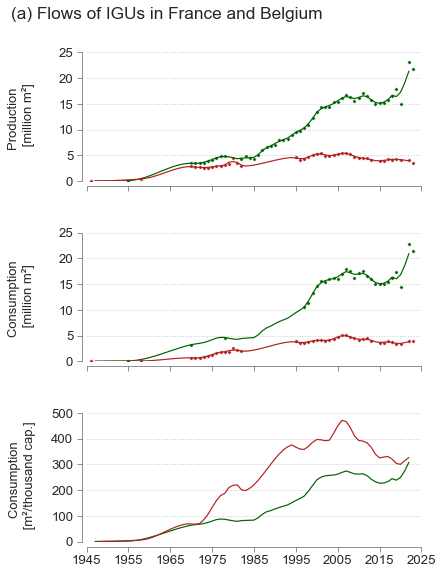

In [181]:
# Plot total flows, moving average w/ a 3-y. window length:
toplot = [(0, 'Production', '[10^6 m²]'),
          (1, 'Consumption', '[10^6 m²]'),
          (2, 'Consumption', '[m²/1000cap]')
          ]

fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

for n, data, unit in toplot:
    ax = axes[n]

    for country in countries:
        # Define the color and title for the subplots:
        if country == 'Belgium':
            color = 'firebrick'
        else:
            color = 'darkgreen'

        (df_be_fr[(data, unit, country)]
         .interpolate(method='pchip').rolling(3, center=True).mean()
         .plot(ax=ax, c=color)
         )

        # Plot raw data:
        if unit == '[10^6 m²]':
            sns.scatterplot(data=df_be_fr_init[data, unit, country],
                            marker='.', s=50, color=color,
                            ax=ax)

            ax.get_legend().remove()
            ax.set_ylim(0, 20)
            ax.set_ylabel(f"{data} \n [million m²]", loc='center', 
                          labelpad=24, fontsize=13)
            ax.set_yticks(np.arange(0, 26, 5))
        else:
            ax.set_ylim(0, 500)
            ax.set_ylabel(f"{data} \n [m²/thousand cap.]", loc='center', 
                          labelpad=15, fontsize=13)
            ax.set_yticks(np.arange(0, 501, 100))

        ax.minorticks_off()
        ax.grid(which='major', axis='y', linestyle=':', linewidth=1)
        style_ax(ax)


ax.set_xlim(1945, 2025)
plt.xticks(np.arange(1945, 2026, 10))


fig.subplots_adjust(hspace=0.4)
fig.suptitle("(a) Flows of IGUs in France and Belgium", 
             x=-0.05, y=0.95, ha='left')
sns.despine(offset=5)

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'Fig4a_BE-FR_IGUFlows.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'Fig4a_BE-FR_IGUFlows.pdf'),
                bbox_inches='tight')

plt.show()

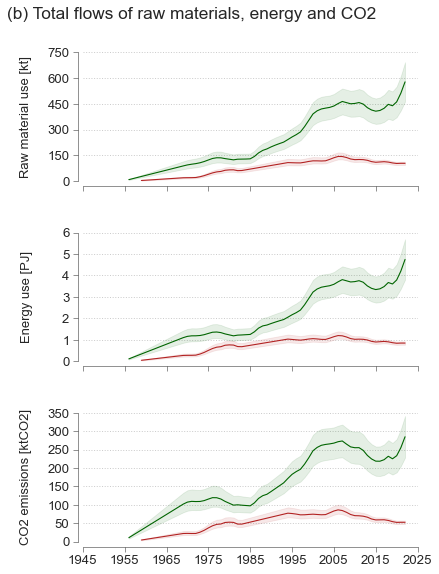

In [182]:
# Plot total energy & material use, total CO2 emissions for IGU consumption:
fig, axes = plt.subplots(nrows=3, ncols=1,
                         sharex=True,
                         figsize=(6, 9))

# Total use of raw materials:
ax = axes[0]
for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total raw materials, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, consumption',
                      '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total raw materials, consumption',
                      '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Raw material use [kt]", labelpad=15, fontsize=13)
style_ax(ax)
ax.set_ylim(0, 750)
ax.set_yticks(np.arange(0, 751, 150))


# Total use of energy:
ax = axes[1]
for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('Total energy, consumption', '[PJ], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('Total energy, consumption',
                      '[PJ], min.', country)],
                    alpha=0.10, color=color)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("Energy use [PJ]", labelpad=29, fontsize=13)
ax.set_xlim(1945, 2025)

style_ax(ax)
ax.set_ylim(0, 6)
ax.set_yticks(np.arange(0, 6.1, 1))

# Total emissions of CO2:
ax = axes[2]
for country in countries:
    # Define the color:
    if country == 'Belgium':
        color = 'firebrick'
    else:
        color = 'darkgreen'

    ax.plot(df_be_fr.interpolate().rolling(3, center=True).mean()
            [('co2, consumption', '[kt], average', country)],
            linewidth=1.1, c=color
            )

    ax.fill_between(df_be_fr.index,
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], max.', country)],
                    df_be_fr.interpolate().rolling(3, center=True).mean()
                    [('co2, consumption', '[kt], min.', country)],
                    alpha=0.10, color=color)

ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

ax.set_ylabel("CO2 emissions [ktCO2]", labelpad=15, fontsize=13)
style_ax(ax)
ax.set_ylim(0, 350)
ax.set_yticks(np.arange(0, 351, 50))

plt.xticks(np.arange(1945, 2026, 10))

fig.suptitle("(b) Total flows of raw materials, energy and CO2",
             x=-0.05, y=0.95, ha='left')
fig.subplots_adjust(hspace=0.4)

sns.despine(offset=5)

if export:
    # Save image:
    plt.savefig(os.path.join(path_img, 'Fig4b_BE-FR_TotalFlows.png'),
                dpi=600, bbox_inches='tight')
    plt.savefig(os.path.join(path_img, 'Fig4b_BE-FR_TotalFlows.pdf'),
                bbox_inches='tight')

plt.show()

## A base 100 analysis, Belgium and France

In [183]:
# Base 100:
D1 = 1980

# Timeframe to plot
D2 = 1970
D3 = 2025

In [184]:
# Base 100, data:
consumption_diff = (100 * df_be_fr['Consumption']
                    / df_be_fr['Consumption'].loc[D1])

co2intensity_diff = 100 * fr_co2_intensity / fr_co2_intensity.loc[D1]

co2abs_diff = (100 * df_be_fr['co2, consumption']
               / df_be_fr['co2, consumption'].loc[D1])

In [185]:
# Base 100, with a 3-year moving average
consumption_diff_roll = (100 * df_be_fr['Consumption']
                         .interpolate(method="linear", limit_area='inside')
                         .rolling(3, center=True).mean()
                         / df_be_fr['Consumption'].interpolate(method="linear", limit_area='inside')
                         .rolling(3, center=True).mean().loc[D1])

co2abs_diff_roll = (100 * df_be_fr['co2, consumption'].interpolate(method="linear", limit_area='inside')
                    .rolling(3, center=True).mean()
                    / df_be_fr['co2, consumption'].interpolate(method="linear", limit_area='inside')
                    .rolling(3, center=True).mean().loc[D1])

Base year analysis, flows of IGU and CO2 in BE and FR, base year = 1980 




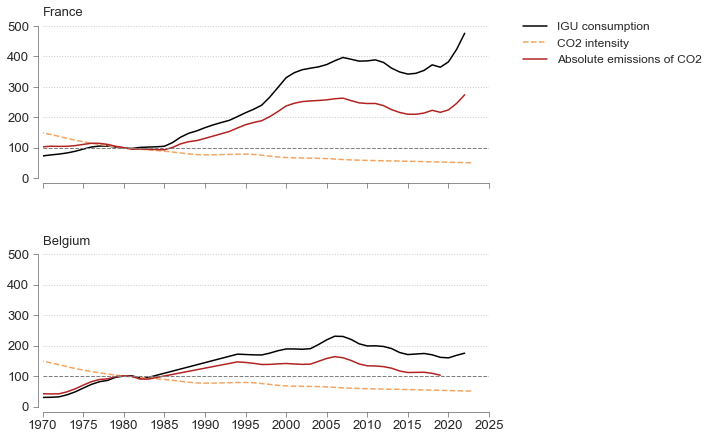

In [197]:
# Plot production, carbon intensity, CO2 absolute emissions:
fig, axes = plt.subplots(nrows=2, ncols=1,
                         sharex=True, sharey=True,
                         figsize=(8, 7))


for row, country in enumerate(countries):
    ax = axes[row]

    sns.lineplot(data=consumption_diff_roll['[10^6 m²]'],
                 x=consumption_diff_roll.index,
                 y=country,
                 ax=ax, color='black', linewidth=1.5)

    ax.plot(co2intensity_diff.index,
            co2intensity_diff['CO2 interpolated [kg/t]'],
            color='sandybrown', linestyle='--', linewidth=1.5)

    ax.plot(co2abs_diff_roll.index,
            co2abs_diff_roll['[kt], average', country],
            color='firebrick', linewidth=1.5)

    ax.set_xlim(D2, D3)
    plt.xticks(np.arange(D2, D3+1, 5))
    ax.set_ylabel(None)

    ax.plot([D2, D3], [100, 100], '--', c='grey', linewidth=1)
    ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

    ax.set_title(country, loc='left', pad=10, fontsize=13)
    style_ax(ax)
    if row == 1:
        ax.legend(labels=[
            "IGU consumption", "CO2 intensity", "Absolute emissions of CO2"
        ], bbox_to_anchor=(1.5, 2.6), frameon=False, fontsize=12)

ax.set_ylim(0, 500)
ax.set_yticks(np.arange(0, 501, 100))

fig.subplots_adjust(hspace=0.5)
sns.despine(offset=5)

print(
    "Base year analysis, flows of IGU and CO2 in BE and FR, base year = 1980",
    "\n\n"
)

if export:
    # Save image:
    fig.savefig(os.path.join(path_img, 'Fig5_IGU_Base100_BE-FR.png'),
                dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(path_img, 'Fig5_IGU_Base100_BE-FR.pdf'),
                bbox_inches='tight')
    
plt.show()

## A base 100 analysis, Europe

In [187]:
# Base 100:
Y1 = 1985

# Timeframe to plot
Y2 = 1970
Y3 = 2025

In [188]:
df_eu_base100 = (df_eu['Estimated consumption']
                 .reset_index(level='Nbr of countries')
                 .drop('Nbr of countries', axis=1)
                 .sort_values(by=['year']))

df_eu_co2_base100 = (df_eu['co2, consumption']
                     .reset_index(level='Nbr of countries')
                     .drop('Nbr of countries', axis=1)
                     .sort_values(by=['year']))

In [189]:
# Base 100 = 1975
consumption_diff_eu = (100 * df_eu_base100['[10^6 m²]']
                       .interpolate(method="linear", limit_area='inside')
                       .rolling(3, center=True).mean()
                       / df_eu_base100['[10^6 m²]']
                       .interpolate(method="linear", limit_area='inside')
                       .rolling(3, center=True).mean().loc[Y1])

co2intensity_diff_eu = 100 * df_eu_co2 / df_eu_co2.loc[Y1]

co2abs_diff_eu = (100 * df_eu_co2_base100['[kt], average']
                  .interpolate(method="linear", limit_area='inside')
                  .rolling(3, center=True).mean()
                  / df_eu_co2_base100['[kt], average']
                  .interpolate(method="linear", limit_area='inside')
                  .rolling(3, center=True).mean().loc[Y1])

Base year analysis, flows of IGU and CO2 in the EU, base year = 1985 




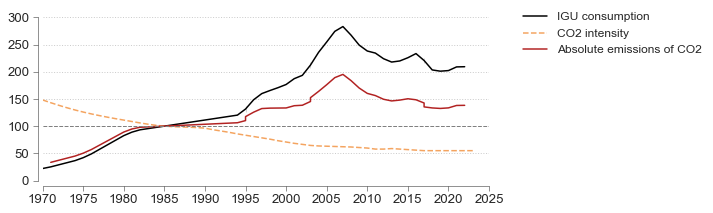

In [193]:
# Plot production, carbon intensity, CO2 absolute emissions:
fig, ax = plt.subplots(figsize=(8, 3))

sns.lineplot(data=consumption_diff_eu, ax=ax, color='black', linewidth=1.5)

ax.plot(co2intensity_diff_eu.index,
        co2intensity_diff_eu['CO2 interpolated [kg/t]'],
        color='sandybrown', linestyle='--', linewidth=1.5)

co2abs_diff_eu.plot(ax=ax, color='firebrick', linewidth=1.5)

ax.set_xlim(Y2, Y3)
plt.xticks(np.arange(Y2, Y3+1, 5))
ax.set_ylabel(None)

ax.plot([Y2, Y3], [100, 100], '--', c='grey', linewidth=1)
ax.grid(which='major', axis='y', linestyle=':', linewidth=1)

style_ax(ax)

ax.set_ylim(0, 300)
plt.yticks(np.arange(0, 301, 50))

plt.legend(labels=["IGU consumption",
                   "CO2 intensity",
                   "Absolute emissions of CO2"],
           bbox_to_anchor=(1.5, 1.1), frameon=False, fontsize=12)

fig.subplots_adjust(hspace=0.5)


sns.despine(offset=5)

print(
    "Base year analysis, flows of IGU and CO2 in the EU, base year = 1985",
    "\n\n")

if export:
    # Save image:
    fig.savefig(os.path.join(path_img, 'Fig6_IGU_Base100_EU.png'),
                dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(path_img, 'Fig6_IGU_Base100_EU.pdf'),
                bbox_inches='tight')
    
plt.show()